# Southend Pier -- Stage 2: UTide-Informed BiLSTM Decoder with Attention (PyTorch)

Stage 2 of the Thames tidal water-level forecasting work. Stage 1
(`initial_modelling.ipynb`) trained single-step LSTM/RNN/MLP models over a
96-step (16h) lookback of `Observed_ODN` and evaluated them at longer
horizons via *recursive* rollout -- feeding each model's own prediction back
in as input. That worked well up to about 1h ahead but degraded badly beyond
6h, while a standalone UTide harmonic reconstruction stayed flat across all
horizons (it's a fixed function of wall-clock time, not autoregressive) and
overtook the neural nets from ~6h onward.

This stage closes that gap with a **direct multi-horizon** forecaster:

- **Encoder**: the same LSTM over 96 lagged `Observed_ODN` values as stage 1
  (same `hidden_size`, `num_layers`, learning rate -- not re-tuned here).
- **Decoder**: a bidirectional LSTM that steps once per forecast horizon,
  fed at each step the UTide harmonic reconstruction for that *exact future
  timestamp* -- fully known in advance, no recursive feedback of the model's
  own output.
- **Attention**: each decoder step attends over all 96 encoder hidden
  states (not just the compressed final state), so the model can look back
  at whichever part of the recent tidal history is most relevant to a given
  horizon.

No meteorological covariates (pressure, discharge, rainfall, wind) are used
here -- that's a later stage. Runtime is sized for a Colab T4, not a large
accelerator; this notebook is not a hyperparameter search.

**Data / site**: Southend Pier tide gauge, River Thames, lat 51.5145 --
`3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv`, 10-minute readings,
2004-2024, chatter/stuck-sensor faults already patched.

**Split** (unchanged from stage 1, chronological, non-overlapping): train
2004-2017, validation 2018-2020, test 2021-2024. All fitting (scaler, UTide,
models) uses train only; validation drives early stopping; test is touched
once, at the end, on the final config only.


## 1. Setup

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported:  {torch.cuda.is_bf16_supported()}")
else:
    print("No GPU detected -- this notebook is sized for a Colab T4 (Runtime > Change runtime "
          "type > T4 GPU). It will still run on CPU, just much slower.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU:             Tesla T4
BF16 supported:  True


In [3]:
SEED = 42

# --- reused verbatim from stage 1 (initial_modelling.ipynb) ---
LOOKBACK = 96        # 16h of 10-minute steps, matches stage 1's encoder window
TRAIN_STRIDE = 3      # subsample training windows every 3rd step (30 min) to cut epoch time
BATCH_SIZE = 512      # halved vs. stage 1's 1024: attention + multi-horizon decoding costs more
                       # memory per sample, and this needs to fit comfortably on a T4, not an A100
EPOCHS = 60
PATIENCE = 10
LR = 1e-3
TRAIN_END = '2018-01-01'
VAL_END = '2021-01-01'

# --- stage-1 encoder hyperparameters, reused (not re-tuned here) ---
ENC_HIDDEN_SIZE = 64
ENC_NUM_LAYERS = 1

# --- new stage-2 decoder hyperparameters -- modest, no sweep in this notebook ---
DEC_HIDDEN_SIZE = 64
DEC_NUM_LAYERS = 1
ATTN_DIM = 64

# --- forecast horizons. The first five match stage 1's rollout comparison (section 13);
# 72h and 168h (1 week) are added here since that's exactly the regime a fixed-in-time UTide
# reconstruction should dominate a lookback-only model, and it's worth seeing how far out that
# advantage (and this stage's attempt to close it) actually holds.
HORIZONS = {'10min': 1, '1h': 6, '6h': 36, '24h': 144, '48h': 288, '72h': 432, '168h': 1008}
HORIZON_NAMES = list(HORIZONS.keys())
HORIZON_STEPS = list(HORIZONS.values())
N_HORIZONS = len(HORIZON_STEPS)

# ~M2 semi-diurnal tidal period in 10-minute steps (12h 25.2min / 10min)
M2_STEPS = 74.5

SITE_LAT = 51.5145  # Southend Pier

STEP = pd.Timedelta('10min')


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
torch.backends.cudnn.benchmark = True


## 2. Load data (Google Drive)

In [4]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/tidal_analysis_and_prediction/10_SOUTHEND_chatter_and_stuck_patched.csv'  # <-- edit if your file lives elsewhere
    OUTPUT_DIR = '/content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs'
else:
    DATA_PATH = '../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv'
    OUTPUT_DIR = '../outputs/stage2_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
assert os.path.exists(DATA_PATH), f"Can't find data at {DATA_PATH} -- update DATA_PATH above."


Mounted at /content/drive


In [5]:
usecols = ['DateTime', 'Observed_ODN', 'is_chatter_flagged', 'is_stuck_flagged', 'is_imputed']
df = pd.read_csv(DATA_PATH, usecols=usecols, parse_dates=['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['is_flagged'] = df['is_chatter_flagged'] | df['is_stuck_flagged'] | df['is_imputed']

gap_mask = df['DateTime'].diff() > STEP
print(f"{len(df):,} rows, {df.DateTime.min()} to {df.DateTime.max()}")
print(f"{gap_mask.sum()} gaps > 10min ({gap_mask.sum() + 1} contiguous segments)")
print(f"Flagged (chatter/stuck/imputed) points: {df['is_flagged'].sum():,} ({100 * df['is_flagged'].mean():.3f}%)")
df.head()


1,103,956 rows, 2004-01-01 00:00:00 to 2024-12-31 23:50:00
90 gaps > 10min (91 contiguous segments)
Flagged (chatter/stuck/imputed) points: 9,975 (0.904%)


,DateTime,is_imputed,Observed_ODN,is_chatter_flagged,is_stuck_flagged,is_flagged
0,2004-01-01 00:00:00,False,-1.819,False,False,False
1,2004-01-01 00:10:00,False,-1.855,False,False,False
2,2004-01-01 00:20:00,False,-1.874,False,False,False
3,2004-01-01 00:30:00,False,-1.895,False,False,False
4,2004-01-01 00:40:00,False,-1.904,False,False,False


## 3. UTide harmonic reconstruction

Fit UTide **only on the training split** (2004-2017) -- fitting on
validation or test data would leak future tidal-phase information the model
should not have at forecast time. Flagged (chatter/stuck/imputed) points are
excluded from the fit, same as stage 1, since those were themselves filled
in via a UTide reconstruction during cleaning (fitting on them would be
circular).

The fitted constituents are then **reconstructed across the entire
2004-2024 span** (`utide_recon`), using `min_SNR=0, min_PE=0` -- the
`reconstruct()` defaults silently drop low-SNR/PE constituents, which would
make this reconstruction inconsistent with a "let the model see everything
UTide has to offer" decoder feature.

`utide_recon` is used two ways below, and both uses come from *this same*
array so the comparison is apples-to-apples:
- as the **decoder input** feature (`UTide(t+k)` at each forecast horizon);
- sliced to the test split, as the **standalone `utide_baseline` comparator**
  in the final evaluation.


In [6]:
try:
    import utide
except ImportError:
    import sys
    !{sys.executable} -m pip install -q UTide
    import utide


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.3/75.3 kB 7.3 MB/s eta 0:00:00


In [7]:
train_mask_full = df['DateTime'] < TRAIN_END

fit_series = df.loc[train_mask_full, 'Observed_ODN'].copy()
fit_series[df.loc[train_mask_full, 'is_flagged']] = np.nan

coef = utide.solve(
    df.loc[train_mask_full, 'DateTime'], fit_series,
    lat=SITE_LAT, method='ols', conf_int='none',
)

recon = utide.reconstruct(pd.DatetimeIndex(df['DateTime']), coef, min_SNR=0, min_PE=0, verbose=False)
df['utide_recon'] = recon['h'].astype(np.float32)

print(f"UTide fit on {train_mask_full.sum():,} training rows "
      f"({(~np.isnan(fit_series)).sum():,} after excluding flagged points).")
print(f"Reconstructed {len(df):,} rows across the full 2004-2024 span.")
df[['DateTime', 'Observed_ODN', 'utide_recon']].head()


solve: matrix prep ... solution ... done.
UTide fit on 735,760 training rows (725,912 after excluding flagged points).
Reconstructed 1,103,956 rows across the full 2004-2024 span.


,DateTime,Observed_ODN,utide_recon
0,2004-01-01 00:00:00,-1.819,-1.201859
1,2004-01-01 00:10:00,-1.855,-1.226715
2,2004-01-01 00:20:00,-1.874,-1.242610
3,2004-01-01 00:30:00,-1.895,-1.249598
4,2004-01-01 00:40:00,-1.904,-1.247636


## 4. Chronological train / validation / test split

Same boundaries as stage 1. Because `utide_recon` was attached to `df`
before splitting, every split's dataframe already carries it.


In [8]:
train_df = df[df['DateTime'] < TRAIN_END].reset_index(drop=True)
val_df = df[(df['DateTime'] >= TRAIN_END) & (df['DateTime'] < VAL_END)].reset_index(drop=True)
test_df = df[df['DateTime'] >= VAL_END].reset_index(drop=True)

for split_name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{split_name:5s}: {len(split):>8,} rows  [{split.DateTime.min()} -> {split.DateTime.max()}]  "
          f"flagged={100 * split['is_flagged'].mean():.3f}%")


train:  735,760 rows  [2004-01-01 00:00:00 -> 2017-12-31 23:50:00]  flagged=1.338%
val  :  157,824 rows  [2018-01-01 00:00:00 -> 2020-12-31 23:50:00]  flagged=0.038%
test :  210,372 rows  [2021-01-01 00:00:00 -> 2024-12-31 23:50:00]  flagged=0.032%


## 5. Windowing

Each sample is an encoder window of `LOOKBACK` past `Observed_ODN` values
plus, for every horizon `k` in `HORIZON_STEPS`, a target `Observed_ODN(t+k)`
and a decoder feature `utide_recon(t+k)` -- fully known in advance, so
there's no recursive feedback of the model's own output anywhere in this
design.

Windows are built independently within each gap-free segment of each split
(never bridging a sensor gap or a split boundary), mirroring stage 1's
`build_windows`. `Flag[i, j]` is `True` if the target for sample `i`,
horizon `j` is imputed/chatter/stuck-flagged -- used both to mask training
loss and to exclude those points from evaluation, same discipline as
stage 1.


In [9]:
def build_windows_multi(sub_df, lookback, horizon_steps):
    sub_df = sub_df.reset_index(drop=True)
    is_gap = sub_df['DateTime'].diff() > STEP
    seg_id = is_gap.cumsum().to_numpy()

    values = sub_df['Observed_ODN'].to_numpy(dtype=np.float32)
    utide_vals = sub_df['utide_recon'].to_numpy(dtype=np.float32)
    flagged = sub_df['is_flagged'].to_numpy()
    times = sub_df['DateTime'].to_numpy()

    max_h = max(horizon_steps)
    horizon_arr = np.array(horizon_steps)

    X_list, Ydec_list, Y_list, Flag_list, Time_list = [], [], [], [], []
    for seg in np.unique(seg_id):
        idx = np.where(seg_id == seg)[0]
        n = len(idx)
        if n < lookback + max_h:
            continue

        seg_values = values[idx]
        seg_utide = utide_vals[idx]
        seg_flag = flagged[idx]
        seg_time = times[idx]

        n_windows = n - lookback - max_h + 1
        enc_windows = np.lib.stride_tricks.sliding_window_view(seg_values, lookback)[:n_windows]
        starts = np.arange(n_windows)
        # window `s` covers positions s .. s+lookback-1; horizon k's target sits at
        # s + (lookback - 1) + k, i.e. k steps after the last encoder value (k=1 -> next step)
        target_positions = starts[:, None] + (lookback - 1) + horizon_arr[None, :]

        X_list.append(enc_windows)
        Ydec_list.append(seg_utide[target_positions])
        Y_list.append(seg_values[target_positions])
        Flag_list.append(seg_flag[target_positions])
        Time_list.append(seg_time[target_positions])

    X = np.concatenate(X_list, axis=0)
    Ydec = np.concatenate(Ydec_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)
    Flag = np.concatenate(Flag_list, axis=0)
    Time = np.concatenate(Time_list, axis=0)
    return X, Ydec, Y, Flag, Time


In [10]:
X_train, Ydec_train, Y_train, Flag_train, Time_train = build_windows_multi(train_df, LOOKBACK, HORIZON_STEPS)
X_val, Ydec_val, Y_val, Flag_val, Time_val = build_windows_multi(val_df, LOOKBACK, HORIZON_STEPS)
X_test, Ydec_test, Y_test, Flag_test, Time_test = build_windows_multi(test_df, LOOKBACK, HORIZON_STEPS)

X_train, Ydec_train, Y_train, Flag_train, Time_train = (
    X_train[::TRAIN_STRIDE], Ydec_train[::TRAIN_STRIDE], Y_train[::TRAIN_STRIDE],
    Flag_train[::TRAIN_STRIDE], Time_train[::TRAIN_STRIDE],
)

print(f"windows -> train: {X_train.shape} (stride {TRAIN_STRIDE}), val: {X_val.shape}, test: {X_test.shape}")
print(f"targets/horizon feature shape (N, {N_HORIZONS}): train {Y_train.shape}, val {Y_val.shape}, test {Y_test.shape}")


windows -> train: (223039, 96) (stride 3), val: (156721, 96), test: (199319, 96)
targets/horizon feature shape (N, 7): train (223039, 7), val (156721, 7), test (199319, 7)


## 6. Scaling

Standardise using the **train split's** `Observed_ODN` mean/std only (same
as stage 1). `utide_recon` is on the same physical footing (metres ODN), so
it's scaled with the *same* scaler rather than fitting a separate one for
it.


In [11]:
train_mean = float(train_df['Observed_ODN'].mean())
train_std = float(train_df['Observed_ODN'].std())
print(f"train mean={train_mean:.4f} m, std={train_std:.4f} m")

def to_tensor(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype, device=device)

def scale(a):
    return (a - train_mean) / train_std

X_train_t = to_tensor(scale(X_train))
Ydec_train_t = to_tensor(scale(Ydec_train))
Y_train_t = to_tensor(scale(Y_train))
Flag_train_t = to_tensor(Flag_train, dtype=torch.bool)

X_val_t = to_tensor(scale(X_val))
Ydec_val_t = to_tensor(scale(Ydec_val))
Y_val_t = to_tensor(scale(Y_val))
Flag_val_t = to_tensor(Flag_val, dtype=torch.bool)

X_test_t = to_tensor(scale(X_test))
Ydec_test_t = to_tensor(scale(Ydec_test))


train mean=0.1459 m, std=1.5730 m


## 7. Baselines

Five non-learned or previously-trained comparators, evaluated on the same
windowed targets as the new model:

1. **Naive persistence** -- hold the last observed value flat across every
   horizon: `pred(t+k) = Observed_ODN(t)`.
2. **Tide-aware persistence** -- hold the value from one M2 cycle
   (~74.5 steps) before the forecast origin flat, wrapping around by
   additional whole M2 cycles for horizons beyond ~74.5 steps so the
   reference point always falls inside the (already-observed) lookback
   window -- this keeps it a fair, causal baseline out to 168h (1 week)
   rather than reaching into the future.
3. **UTide standalone** (`utide_baseline`) -- the harmonic reconstruction
   alone, i.e. exactly the decoder feature `Ydec_test`, evaluated as a
   prediction in its own right.
4. **Stage-1 baseline (flat LSTM)** and **5. Stage-1 baseline (flat MLP)**
   -- reproduced below (section 9) using stage 1's exact architectures
   (`LSTMModel`'s `hidden_size`/`num_layers`/`LR`, and `MLP`'s
   `hidden=(128, 64)`) but with a flat linear head over all horizons at
   once, since stage 1's notebook did not persist a direct multi-horizon
   checkpoint -- only single-step models evaluated via recursive rollout.
   These are the fairest like-for-like comparators: same encoders, same
   masking/split/training discipline, the only difference being the new
   decoder.


In [12]:
def masked_rmse_mae(pred, true, flagged):
    # pred, true, flagged: (N, H) arrays -- returns per-horizon RMSE/MAE with flagged targets excluded.
    rmses, maes = [], []
    for j in range(pred.shape[1]):
        mask = ~flagged[:, j]
        err = pred[mask, j] - true[mask, j]
        rmses.append(float(np.sqrt(np.mean(err ** 2))))
        maes.append(float(np.mean(np.abs(err))))
    return np.array(rmses), np.array(maes)


def naive_persistence(X_raw, n_horizons):
    return np.repeat(X_raw[:, -1:], n_horizons, axis=1)


def tide_aware_persistence(X_raw, horizon_steps, m2_steps=M2_STEPS, lookback=LOOKBACK):
    # pred(t+k) = Observed_ODN(t + ref), where ref is k shifted back by whole M2 cycles
    # until it lands at or before the forecast origin (ref <= 0) -- so long horizons (e.g. 48h)
    # still only use already-observed history, with linear interpolation between the two nearest
    # lag steps since m2_steps isn't an integer.
    preds = np.zeros((X_raw.shape[0], len(horizon_steps)), dtype=np.float32)
    for j, k in enumerate(horizon_steps):
        ref = float(k) - m2_steps
        while ref >= -1e-9:
            ref -= m2_steps
        float_idx = lookback + ref  # fractional position within the lookback array
        idx0 = int(np.floor(float_idx))
        idx0 = max(0, min(idx0, lookback - 1))
        idx1 = min(idx0 + 1, lookback - 1)
        weight = float_idx - idx0
        preds[:, j] = (1 - weight) * X_raw[:, idx0] + weight * X_raw[:, idx1]
    return preds


In [13]:
results = []

naive_test = naive_persistence(X_test, N_HORIZONS)
rmse, mae = masked_rmse_mae(naive_test, Y_test, Flag_test)
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'Naive persistence', 'horizon': hname, 'rmse_m': rmse[j], 'mae_m': mae[j]})

tide_pers_test = tide_aware_persistence(X_test, HORIZON_STEPS)
rmse, mae = masked_rmse_mae(tide_pers_test, Y_test, Flag_test)
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'Tide-aware persistence', 'horizon': hname, 'rmse_m': rmse[j], 'mae_m': mae[j]})

# utide_baseline: the standalone comparator required alongside utide_recon. It is, by
# construction, the exact same reconstruction (same coef, same reconstruct() call) as the
# decoder feature above -- just sliced to the windowed test targets and used as a prediction
# in its own right, so the feature the model sees and the benchmark it's judged against can
# never diverge because of a constituent-selection difference.
utide_baseline = Ydec_test

rmse, mae = masked_rmse_mae(utide_baseline, Y_test, Flag_test)
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'UTide standalone', 'horizon': hname, 'rmse_m': rmse[j], 'mae_m': mae[j]})

pd.DataFrame(results).pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].round(4)


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1329,0.7859,3.0826,0.7156,1.2962,1.8294,2.9235
Tide-aware persistence,0.4381,0.4379,0.4377,0.3802,0.5249,0.6975,1.1185
UTide standalone,0.2454,0.2454,0.2453,0.2445,0.2439,0.2438,0.2456


## 8. Models

### 8a. Shared encoder

Same LSTM encoder as stage 1's `LSTMModel`, but returning the full sequence
of hidden states (`enc_outputs`) as well as the final `(h_n, c_n)`, so the
decoder's attention can look back over the whole 96-step history rather
than only the compressed final state.


In [14]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

    def forward(self, x):  # x: (B, T_hist, input_size)
        enc_outputs, (h_n, c_n) = self.lstm(x)
        return enc_outputs, (h_n, c_n)


### 8b. Attention

Standard additive-style dot-product attention: project both the decoder's
current output and every encoder hidden state into a shared `attn_dim`,
score them, softmax over the history axis, and take the weighted sum of
encoder outputs as context.


In [15]:
class BatchedAttention(nn.Module):
    def __init__(self, dec_dim, enc_dim, attn_dim):
        super().__init__()
        self.dec_proj = nn.Linear(dec_dim, attn_dim)
        self.enc_proj = nn.Linear(enc_dim, attn_dim)

    def forward(self, dec_out, enc_outputs):
        q = self.dec_proj(dec_out)               # (B, H, attn_dim)
        k = self.enc_proj(enc_outputs)            # (B, T_hist, attn_dim)
        scores = torch.bmm(q, k.transpose(1, 2))  # (B, H, T_hist)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, enc_outputs)  # (B, H, enc_dim)
        return context, weights


### 8c. Decoder

A bidirectional LSTM that takes one step per forecast horizon, with input
`UTide(t+k)` at step `k`. Its initial hidden/cell state is projected from
the encoder's **final layer** final hidden state (if the encoder has more
than one layer, only the last layer's state seeds the decoder -- the usual
convention). This generalises the reference sketch to arbitrary
encoder/decoder layer counts: the reference version's `.view(2, ...)`
reshape only works for a single-layer encoder feeding a single-layer
bidirectional decoder, so here the projection targets
`num_layers * 2 * hidden_size` and is reshaped with an explicit
`(B, layers*directions, hidden) -> (layers*directions, B, hidden)`
permute, which is correct for any layer count.

At each decoder step, attention pulls context from the encoder's history,
and the final per-horizon prediction is a linear readout of
`[decoder_output; attention_context]`.


In [16]:
class TidalDecoder(nn.Module):
    def __init__(self, feat_size, hidden_size, enc_hidden_size, num_layers=1, attn_dim=None):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        attn_dim = attn_dim or hidden_size

        self.lstm = nn.LSTM(feat_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.init_h = nn.Linear(enc_hidden_size, num_layers * 2 * hidden_size)
        self.init_c = nn.Linear(enc_hidden_size, num_layers * 2 * hidden_size)
        self.attn = BatchedAttention(2 * hidden_size, enc_hidden_size, attn_dim)
        self.out = nn.Linear(2 * hidden_size + enc_hidden_size, 1)

    def forward(self, utide_future, enc_outputs, enc_final):
        h_n, c_n = enc_final                       # each (enc_num_layers, B, enc_hidden_size)
        h_last, c_last = h_n[-1], c_n[-1]           # final encoder layer only: (B, enc_hidden_size)
        B = h_last.size(0)

        h0 = self.init_h(h_last).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()
        c0 = self.init_c(c_last).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()

        dec_out, _ = self.lstm(utide_future, (h0, c0))       # (B, H, 2*hidden_size)
        context, weights = self.attn(dec_out, enc_outputs)   # (B, H, enc_hidden_size)
        combined = torch.cat([dec_out, context], dim=-1)
        return self.out(combined).squeeze(-1), weights        # (B, H)


### 8d. Full model and the stage-1 comparators

In [17]:
class TidalSeq2Seq(nn.Module):
    # Stage 2: LSTM encoder + attention + BiLSTM decoder fed known-future UTide values.

    def __init__(self, enc_hidden_size, enc_num_layers, dec_hidden_size, dec_num_layers, attn_dim):
        super().__init__()
        self.encoder = Encoder(1, enc_hidden_size, enc_num_layers)
        self.decoder = TidalDecoder(1, dec_hidden_size, enc_hidden_size, dec_num_layers, attn_dim)

    def forward(self, x_hist, utide_future):
        enc_outputs, enc_final = self.encoder(x_hist.unsqueeze(-1))
        preds, weights = self.decoder(utide_future.unsqueeze(-1), enc_outputs, enc_final)
        return preds, weights


class FlatMultiHorizonLSTM(nn.Module):
    # Stage-1 reproduction: same LSTM encoder, but a flat linear head predicting all horizons
    # at once from the final hidden state -- no decoder, no UTide input, no attention. Stage 1's
    # own notebook only ever trained single-step models (evaluated via recursive rollout), so this
    # is trained here, with stage 1's exact encoder hyperparameters, as the fair direct-multi-horizon
    # baseline the new architecture needs to beat.

    def __init__(self, hidden_size, num_layers, n_horizons):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, n_horizons)

    def forward(self, x_hist):
        out, _ = self.lstm(x_hist.unsqueeze(-1))
        return self.head(out[:, -1, :])


class FlatMultiHorizonMLP(nn.Module):
    # Stage-1 reproduction of stage 1's MLP(lookback, hidden=(128, 64)): same body, but the
    # final layer predicts all horizons at once instead of a single next-step value.

    def __init__(self, lookback, n_horizons, hidden=(128, 64)):
        super().__init__()
        dims = [lookback, *hidden]
        layers = []
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], n_horizons))
        self.net = nn.Sequential(*layers)

    def forward(self, x_hist):
        return self.net(x_hist)


## 9. Training

Masked MSE over all (sample, horizon) pairs, excluding flagged targets --
same discipline as stage 1, extended to the horizon axis. All three models
share one training loop; a `predict_fn` closure adapts it to each model's
input signature (the flat LSTM and flat MLP share the same `predict_flat`
signature since both take just `X`).


In [18]:
def batch_iter(tensors, batch_size, shuffle):
    n = tensors['X'].shape[0]
    idx = torch.randperm(n, device=tensors['X'].device) if shuffle else torch.arange(n, device=tensors['X'].device)
    for start in range(0, n, batch_size):
        b = idx[start:start + batch_size]
        yield {k: v[b] for k, v in tensors.items()}


def masked_mse(pred, true, flag_b):
    return ((pred - true) ** 2)[~flag_b].mean()


def train_model(model, predict_fn, train_tensors, val_tensors, epochs, batch_size, lr, patience, label):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    use_amp = device.type == 'cuda'

    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss, n_seen = 0.0, 0
        for batch in batch_iter(train_tensors, batch_size, shuffle=True):
            opt.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                pred = predict_fn(model, batch)
                loss = masked_mse(pred, batch['Y'], batch['Flag'])
            loss.backward()
            opt.step()
            n_valid = int((~batch['Flag']).sum())
            running_loss += loss.item() * n_valid
            n_seen += n_valid
        train_loss = running_loss / n_seen

        model.eval()
        val_loss_sum, n_val = 0.0, 0
        with torch.no_grad():
            for batch in batch_iter(val_tensors, batch_size, shuffle=False):
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                    pred = predict_fn(model, batch)
                    loss = masked_mse(pred, batch['Y'], batch['Flag'])
                n_valid = int((~batch['Flag']).sum())
                val_loss_sum += loss.item() * n_valid
                n_val += n_valid
        val_loss = val_loss_sum / n_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        sched.step(val_loss)

        improved = val_loss < best_val - 1e-6
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"[{label}] epoch {epoch + 1:03d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}"
              f"  lr={opt.param_groups[0]['lr']:.1e}{'  *' if improved else ''}")

        if epochs_no_improve >= patience:
            print(f"[{label}] early stopping at epoch {epoch + 1} (best val_loss={best_val:.5f})")
            break

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def compute_metrics(model, predict_fn, tensors, y_raw, flagged, batch_size=4096):
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k != 'Y' and k != 'Flag'}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * train_std + train_mean
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae, preds_m


In [19]:
train_tensors_flat = {'X': X_train_t, 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors_flat = {'X': X_val_t, 'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors_flat = {'X': X_test_t}

train_tensors_seq2seq = {'X': X_train_t, 'Ydec': Ydec_train_t, 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors_seq2seq = {'X': X_val_t, 'Ydec': Ydec_val_t, 'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors_seq2seq = {'X': X_test_t, 'Ydec': Ydec_test_t}

predict_flat = lambda model, batch: model(batch['X'])
predict_seq2seq = lambda model, batch: model(batch['X'], batch['Ydec'])[0]


### 9a. Stage-1 baseline (reproduced): flat multi-horizon LSTM

In [20]:
set_seed()
stage1_lstm_model = FlatMultiHorizonLSTM(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, N_HORIZONS).to(device)
stage1_lstm_model, stage1_lstm_history = train_model(
    stage1_lstm_model, predict_flat, train_tensors_flat, val_tensors_flat,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage1-lstm',
)


[stage1-lstm] epoch 001  train_loss=0.17849  val_loss=0.09705  lr=1.0e-03  *
[stage1-lstm] epoch 002  train_loss=0.09152  val_loss=0.08743  lr=1.0e-03  *
[stage1-lstm] epoch 003  train_loss=0.08647  val_loss=0.08962  lr=1.0e-03
[stage1-lstm] epoch 004  train_loss=0.08437  val_loss=0.08287  lr=1.0e-03  *
[stage1-lstm] epoch 005  train_loss=0.08317  val_loss=0.08215  lr=1.0e-03  *
[stage1-lstm] epoch 006  train_loss=0.08202  val_loss=0.08062  lr=1.0e-03  *
[stage1-lstm] epoch 007  train_loss=0.08065  val_loss=0.08049  lr=1.0e-03  *
[stage1-lstm] epoch 008  train_loss=0.07941  val_loss=0.08121  lr=1.0e-03
[stage1-lstm] epoch 009  train_loss=0.07779  val_loss=0.07700  lr=1.0e-03  *
[stage1-lstm] epoch 010  train_loss=0.07715  val_loss=0.07699  lr=1.0e-03  *
[stage1-lstm] epoch 011  train_loss=0.07555  val_loss=0.07543  lr=1.0e-03  *
[stage1-lstm] epoch 012  train_loss=0.07480  val_loss=0.07309  lr=1.0e-03  *
[stage1-lstm] epoch 013  train_loss=0.07412  val_loss=0.07449  lr=1.0e-03
[stage1-

### 9b. Stage-1 baseline (reproduced): flat multi-horizon MLP

In [21]:
set_seed()
stage1_mlp_model = FlatMultiHorizonMLP(LOOKBACK, N_HORIZONS).to(device)
stage1_mlp_model, stage1_mlp_history = train_model(
    stage1_mlp_model, predict_flat, train_tensors_flat, val_tensors_flat,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage1-mlp',
)


[stage1-mlp] epoch 001  train_loss=0.12685  val_loss=0.09509  lr=1.0e-03  *
[stage1-mlp] epoch 002  train_loss=0.08762  val_loss=0.08078  lr=1.0e-03  *
[stage1-mlp] epoch 003  train_loss=0.08029  val_loss=0.08185  lr=1.0e-03
[stage1-mlp] epoch 004  train_loss=0.07822  val_loss=0.07947  lr=1.0e-03  *
[stage1-mlp] epoch 005  train_loss=0.07664  val_loss=0.07540  lr=1.0e-03  *
[stage1-mlp] epoch 006  train_loss=0.07526  val_loss=0.07314  lr=1.0e-03  *
[stage1-mlp] epoch 007  train_loss=0.07434  val_loss=0.07447  lr=1.0e-03
[stage1-mlp] epoch 008  train_loss=0.07353  val_loss=0.07275  lr=1.0e-03  *
[stage1-mlp] epoch 009  train_loss=0.07288  val_loss=0.07269  lr=1.0e-03  *
[stage1-mlp] epoch 010  train_loss=0.07234  val_loss=0.07147  lr=1.0e-03  *
[stage1-mlp] epoch 011  train_loss=0.07204  val_loss=0.07122  lr=1.0e-03  *
[stage1-mlp] epoch 012  train_loss=0.07139  val_loss=0.07076  lr=1.0e-03  *
[stage1-mlp] epoch 013  train_loss=0.07106  val_loss=0.07212  lr=1.0e-03
[stage1-mlp] epoch 01

### 9c. Stage-2 model: encoder + attention + UTide-informed BiLSTM decoder

In [22]:
set_seed()
stage2_model = TidalSeq2Seq(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ATTN_DIM).to(device)
stage2_model, stage2_history = train_model(
    stage2_model, predict_seq2seq, train_tensors_seq2seq, val_tensors_seq2seq,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage2-attn',
)


[stage2-attn] epoch 001  train_loss=0.09252  val_loss=0.01961  lr=1.0e-03  *
[stage2-attn] epoch 002  train_loss=0.01829  val_loss=0.01703  lr=1.0e-03  *
[stage2-attn] epoch 003  train_loss=0.01669  val_loss=0.01633  lr=1.0e-03  *
[stage2-attn] epoch 004  train_loss=0.01592  val_loss=0.01558  lr=1.0e-03  *
[stage2-attn] epoch 005  train_loss=0.01558  val_loss=0.01556  lr=1.0e-03  *
[stage2-attn] epoch 006  train_loss=0.01536  val_loss=0.01522  lr=1.0e-03  *
[stage2-attn] epoch 007  train_loss=0.01519  val_loss=0.01528  lr=1.0e-03
[stage2-attn] epoch 008  train_loss=0.01500  val_loss=0.01525  lr=1.0e-03
[stage2-attn] epoch 009  train_loss=0.01486  val_loss=0.01527  lr=1.0e-03
[stage2-attn] epoch 010  train_loss=0.01470  val_loss=0.01479  lr=1.0e-03  *
[stage2-attn] epoch 011  train_loss=0.01458  val_loss=0.01478  lr=1.0e-03  *
[stage2-attn] epoch 012  train_loss=0.01448  val_loss=0.01458  lr=1.0e-03  *
[stage2-attn] epoch 013  train_loss=0.01445  val_loss=0.01485  lr=1.0e-03
[stage2-att

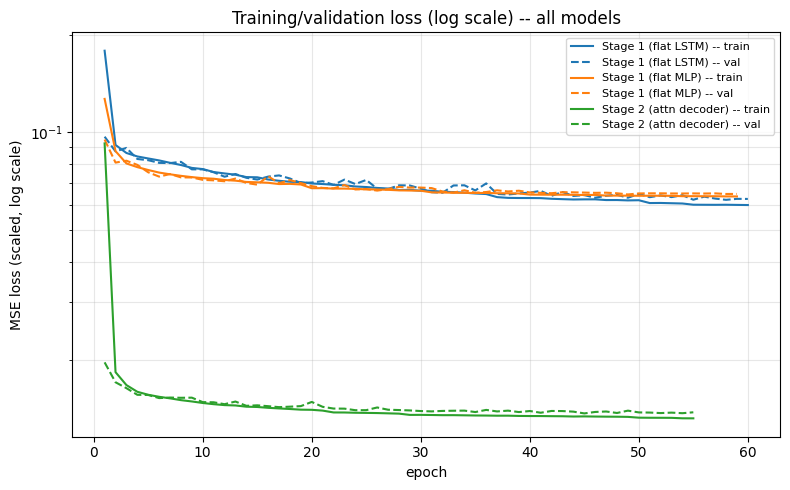

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_loss_curves_combined.png


In [23]:
loss_histories = [
    ('Stage 1 (flat LSTM)', stage1_lstm_history),
    ('Stage 1 (flat MLP)', stage1_mlp_history),
    ('Stage 2 (attn decoder)', stage2_history),
]

# combined log-loss plot -- all three models' train/val curves on one axis, so convergence
# speed and final loss level can be compared directly rather than eyeballing separate panels.
plt.figure(figsize=(8, 5))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for color, (name, history) in zip(colors, loss_histories):
    epochs_arr = np.arange(1, len(history['train_loss']) + 1)
    plt.plot(epochs_arr, history['train_loss'], label=f'{name} -- train', color=color, linestyle='-')
    plt.plot(epochs_arr, history['val_loss'], label=f'{name} -- val', color=color, linestyle='--')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss (scaled, log scale)')
plt.title('Training/validation loss (log scale) -- all models')
plt.legend(fontsize=8)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
combined_loss_curve_path = os.path.join(OUTPUT_DIR, 'stage2_loss_curves_combined.png')
plt.savefig(combined_loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {combined_loss_curve_path}")


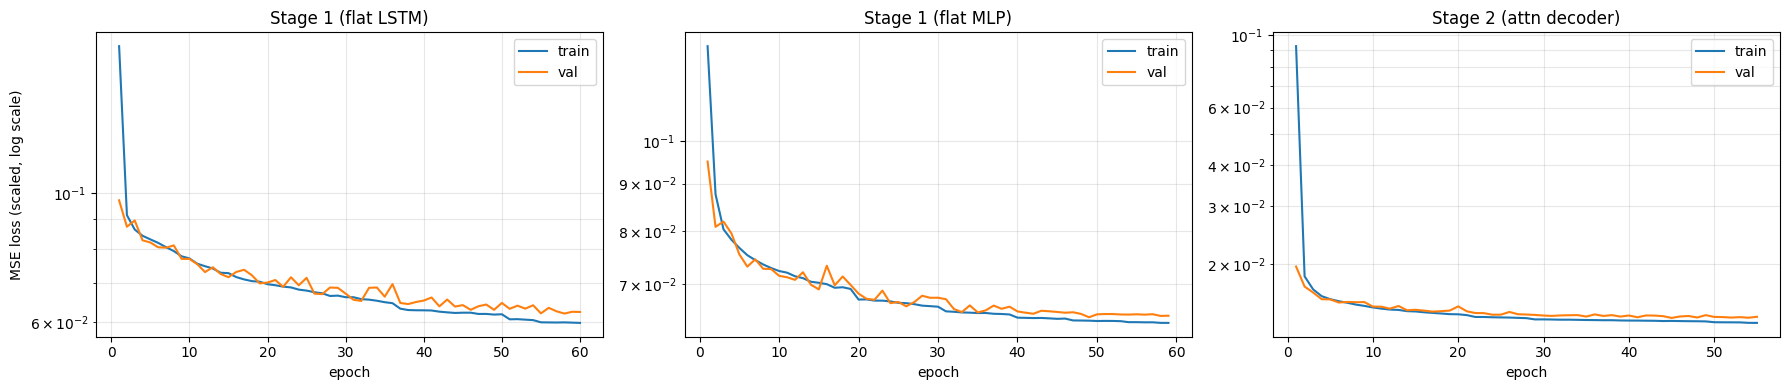

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_loss_curves.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, history) in zip(axes, loss_histories):
    epochs_arr = np.arange(1, len(history['train_loss']) + 1)
    ax.plot(epochs_arr, history['train_loss'], label='train')
    ax.plot(epochs_arr, history['val_loss'], label='val')
    ax.set_yscale('log')
    ax.set_xlabel('epoch')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3, which='both')
axes[0].set_ylabel('MSE loss (scaled, log scale)')
plt.tight_layout()
loss_curve_path = os.path.join(OUTPUT_DIR, 'stage2_loss_curves.png')
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {loss_curve_path}")


## 10. Evaluation (test set, touched once)

RMSE/MAE per horizon for all six comparators: naive persistence,
tide-aware persistence, UTide standalone, the reproduced stage-1 flat LSTM,
the reproduced stage-1 flat MLP, and this stage's attention decoder.


In [25]:
rmse_s1_lstm, mae_s1_lstm, test_preds_s1_lstm = compute_metrics(
    stage1_lstm_model, predict_flat, test_tensors_flat, Y_test, Flag_test)
rmse_s1_mlp, mae_s1_mlp, test_preds_s1_mlp = compute_metrics(
    stage1_mlp_model, predict_flat, test_tensors_flat, Y_test, Flag_test)
rmse_s2, mae_s2, test_preds_s2 = compute_metrics(
    stage2_model, predict_seq2seq, test_tensors_seq2seq, Y_test, Flag_test)

for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'Stage-1 baseline (flat LSTM)', 'horizon': hname, 'rmse_m': rmse_s1_lstm[j], 'mae_m': mae_s1_lstm[j]})
    results.append({'model': 'Stage-1 baseline (flat MLP)', 'horizon': hname, 'rmse_m': rmse_s1_mlp[j], 'mae_m': mae_s1_mlp[j]})
    results.append({'model': 'Stage-2 (attn decoder)', 'horizon': hname, 'rmse_m': rmse_s2[j], 'mae_m': mae_s2[j]})

metrics_df = pd.DataFrame(results)
metrics_path = os.path.join(OUTPUT_DIR, 'stage2_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"saved {metrics_path}")

metrics_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].round(4)


saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_metrics.csv


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1329,0.7859,3.0826,0.7156,1.2962,1.8294,2.9235
Stage-1 baseline (flat LSTM),0.0239,0.0708,0.2567,0.2996,0.3858,0.5009,0.7840
Stage-1 baseline (flat MLP),0.0296,0.0667,0.2488,0.2923,0.3865,0.5089,0.7992
Stage-2 (attn decoder),0.0173,0.0519,0.1882,0.2230,0.2260,0.2284,0.2347
Tide-aware persistence,0.4381,0.4379,0.4377,0.3802,0.5249,0.6975,1.1185
UTide standalone,0.2454,0.2454,0.2453,0.2445,0.2439,0.2438,0.2456


In [26]:
metrics_df.pivot(index='model', columns='horizon', values='mae_m')[HORIZON_NAMES].round(4)


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1181,0.6994,2.7221,0.6068,1.1302,1.6096,2.6080
Stage-1 baseline (flat LSTM),0.0172,0.0510,0.1883,0.2203,0.2971,0.3903,0.6018
Stage-1 baseline (flat MLP),0.0216,0.0478,0.1820,0.2144,0.2991,0.3986,0.6205
Stage-2 (attn decoder),0.0118,0.0365,0.1330,0.1545,0.1594,0.1614,0.1676
Tide-aware persistence,0.3268,0.3267,0.3266,0.2782,0.4064,0.5545,0.9179
UTide standalone,0.1771,0.1771,0.1770,0.1766,0.1764,0.1763,0.1772


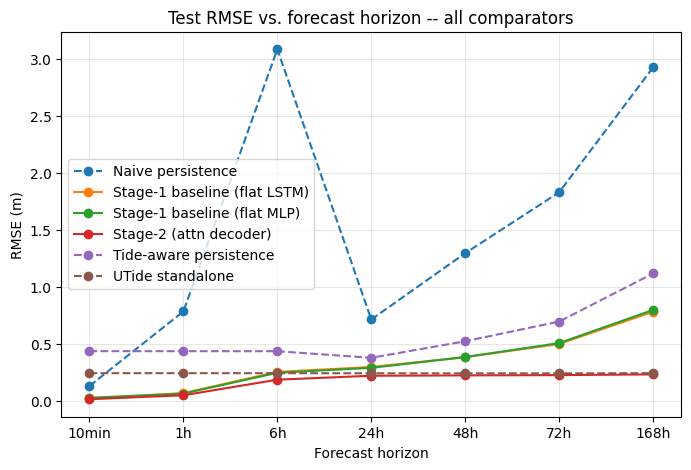

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_vs_horizon.png


In [27]:
plt.figure(figsize=(8, 5))
rmse_pivot = metrics_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES]
for name in rmse_pivot.index:
    style = '--' if 'UTide' in name or 'persistence' in name else '-'
    plt.plot(rmse_pivot.columns, rmse_pivot.loc[name], marker='o', linestyle=style, label=name)
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE (m)')
plt.title('Test RMSE vs. forecast horizon -- all comparators')
plt.legend()
plt.grid(alpha=0.3)
rmse_curve_path = os.path.join(OUTPUT_DIR, 'stage2_rmse_vs_horizon.png')
plt.savefig(rmse_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {rmse_curve_path}")


## 11. Rollout comparison plots (predicted vs. observed, per horizon)

A 14-day sample window from the test set, observed vs. predicted -- one
**separate figure per model**, each with one panel per horizon (since each
horizon's target timestamps are offset differently from the encoder window
they're predicted from). Splitting by model rather than overlaying all six
on one panel keeps each figure readable now that there are six comparators
and seven horizons out to a full week.


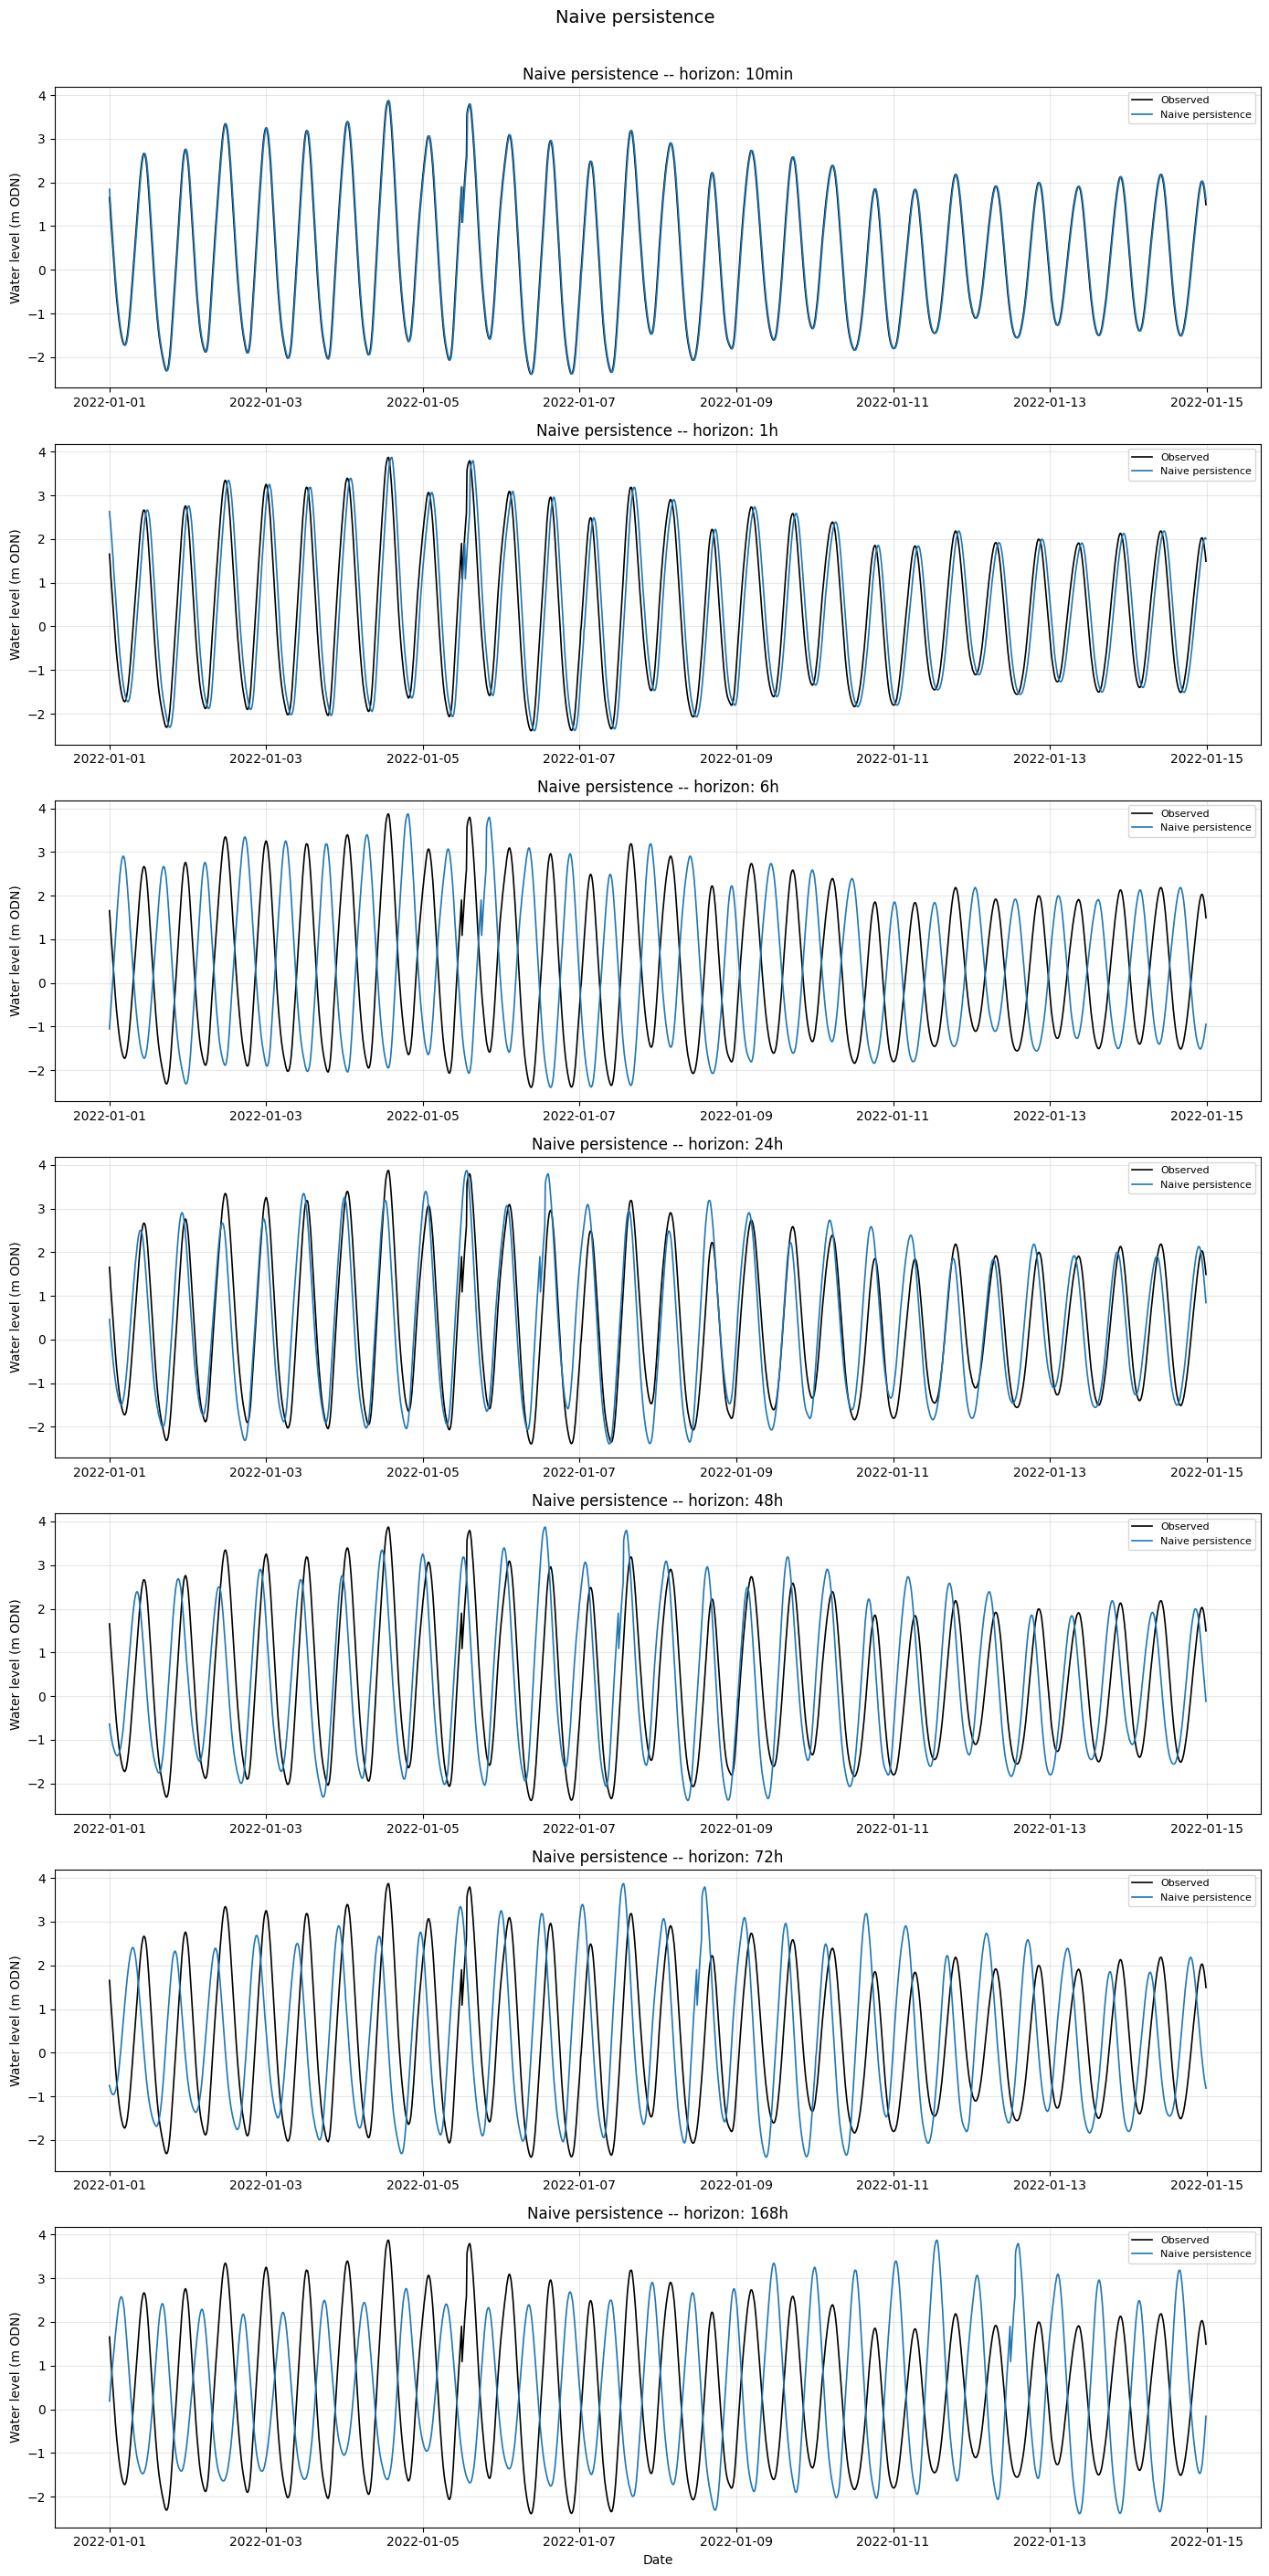

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_naive_persistence.png


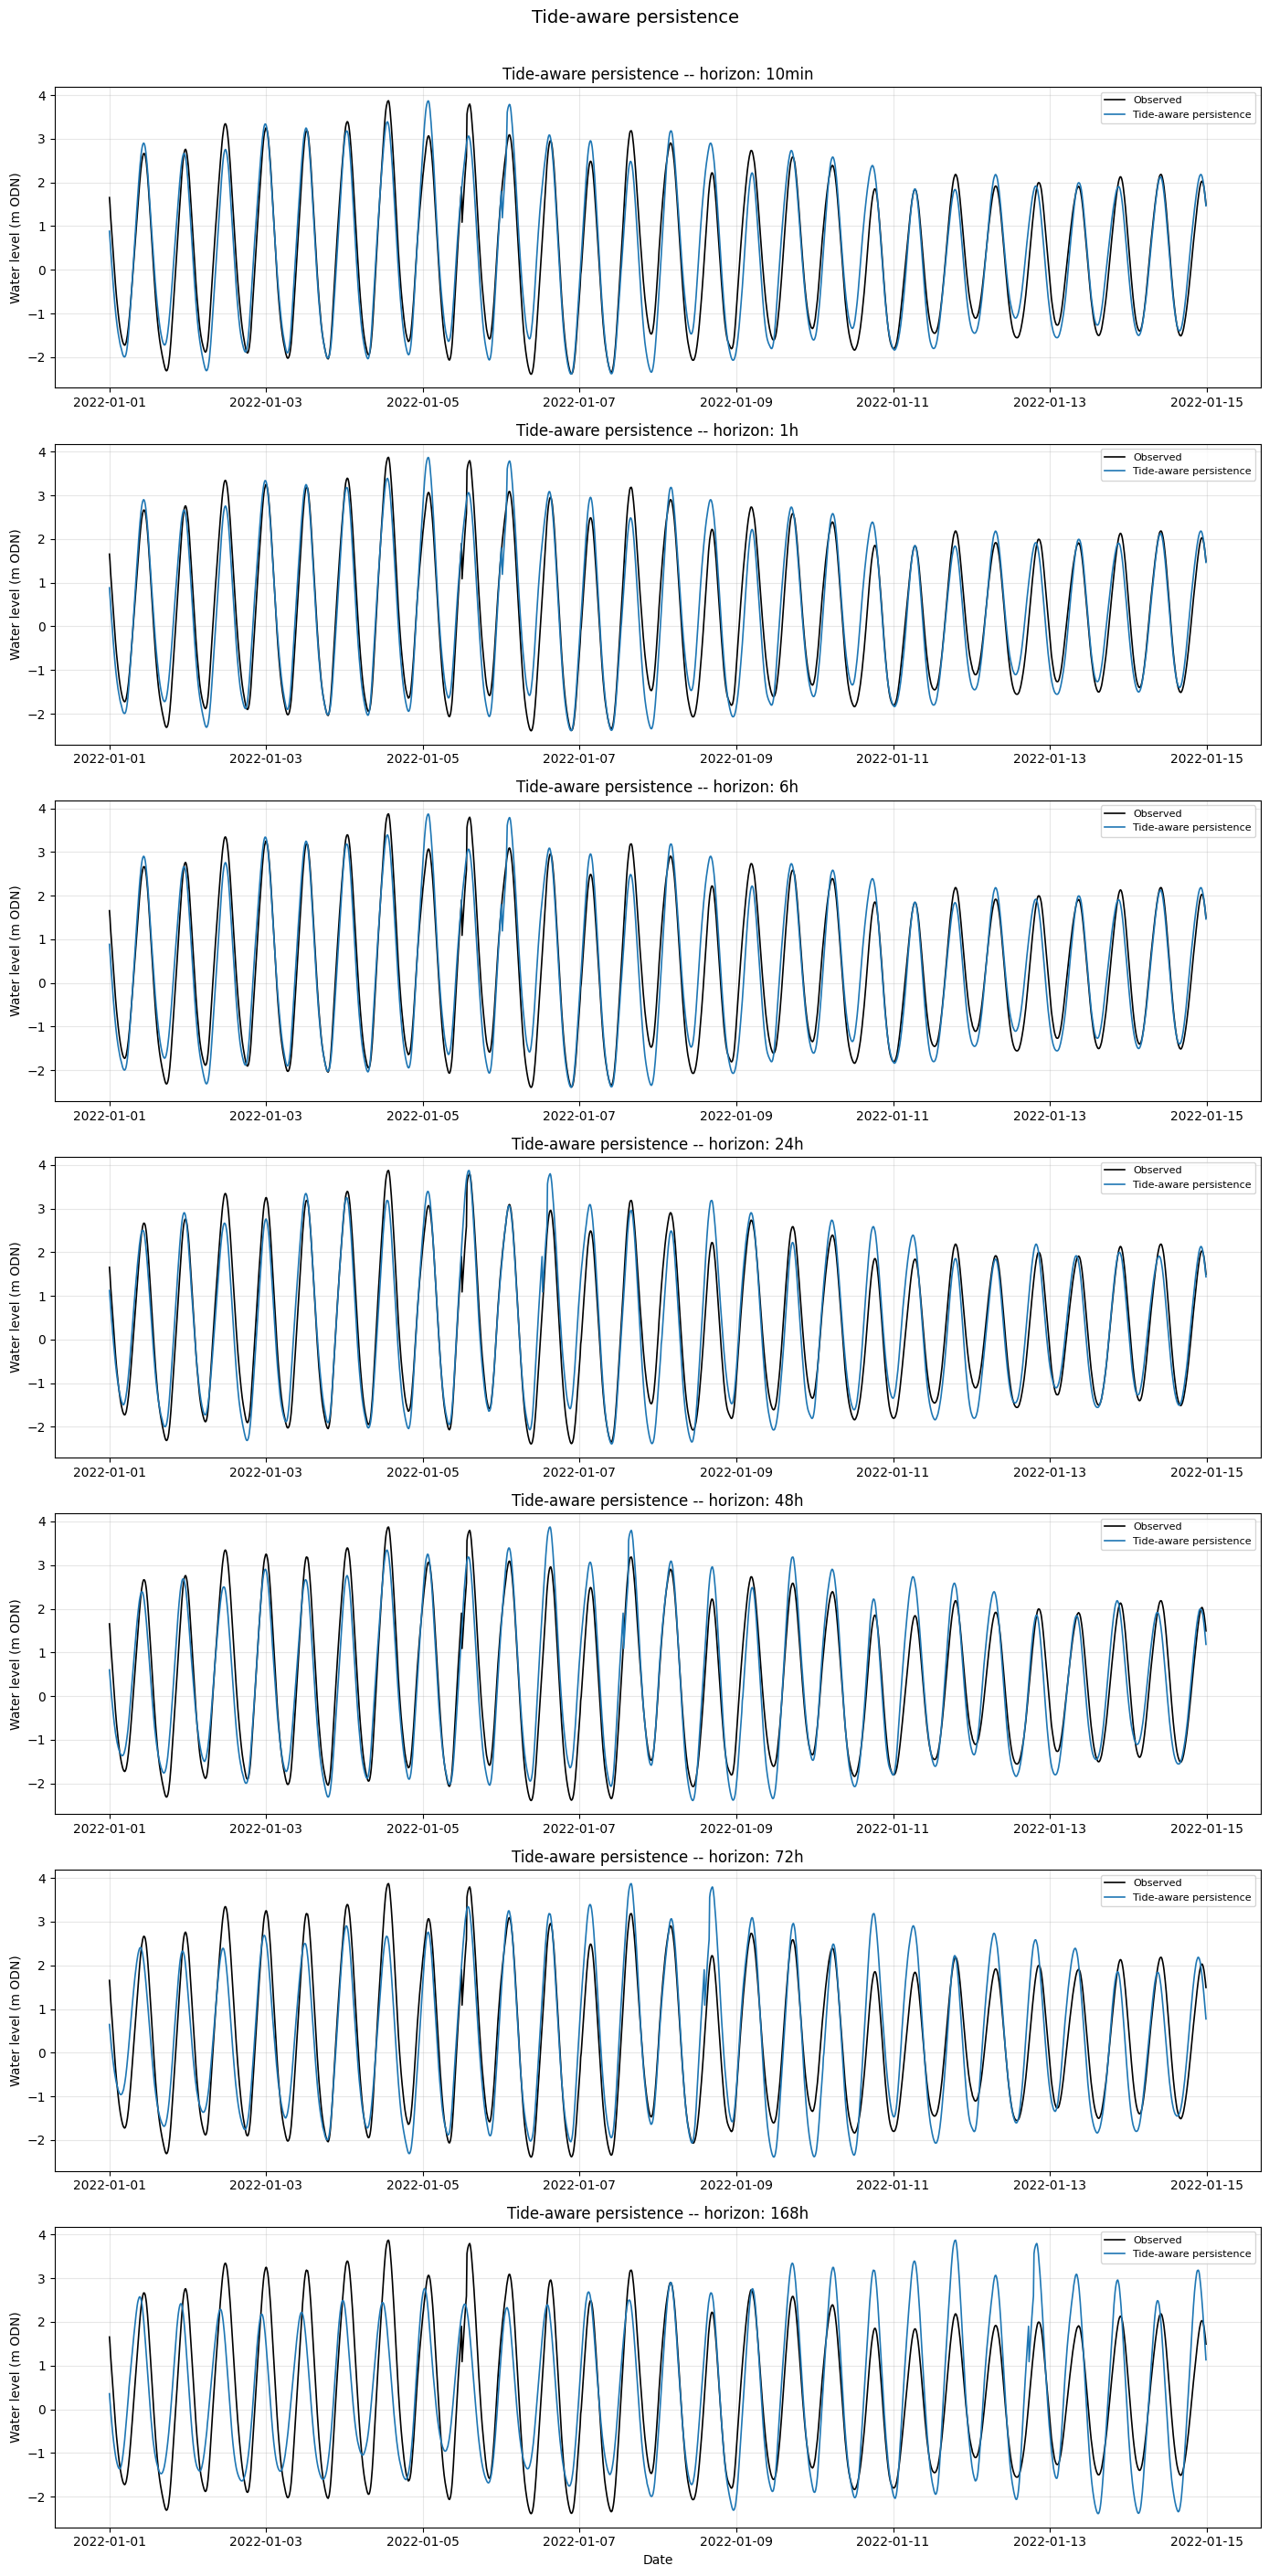

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_tide-aware_persistence.png


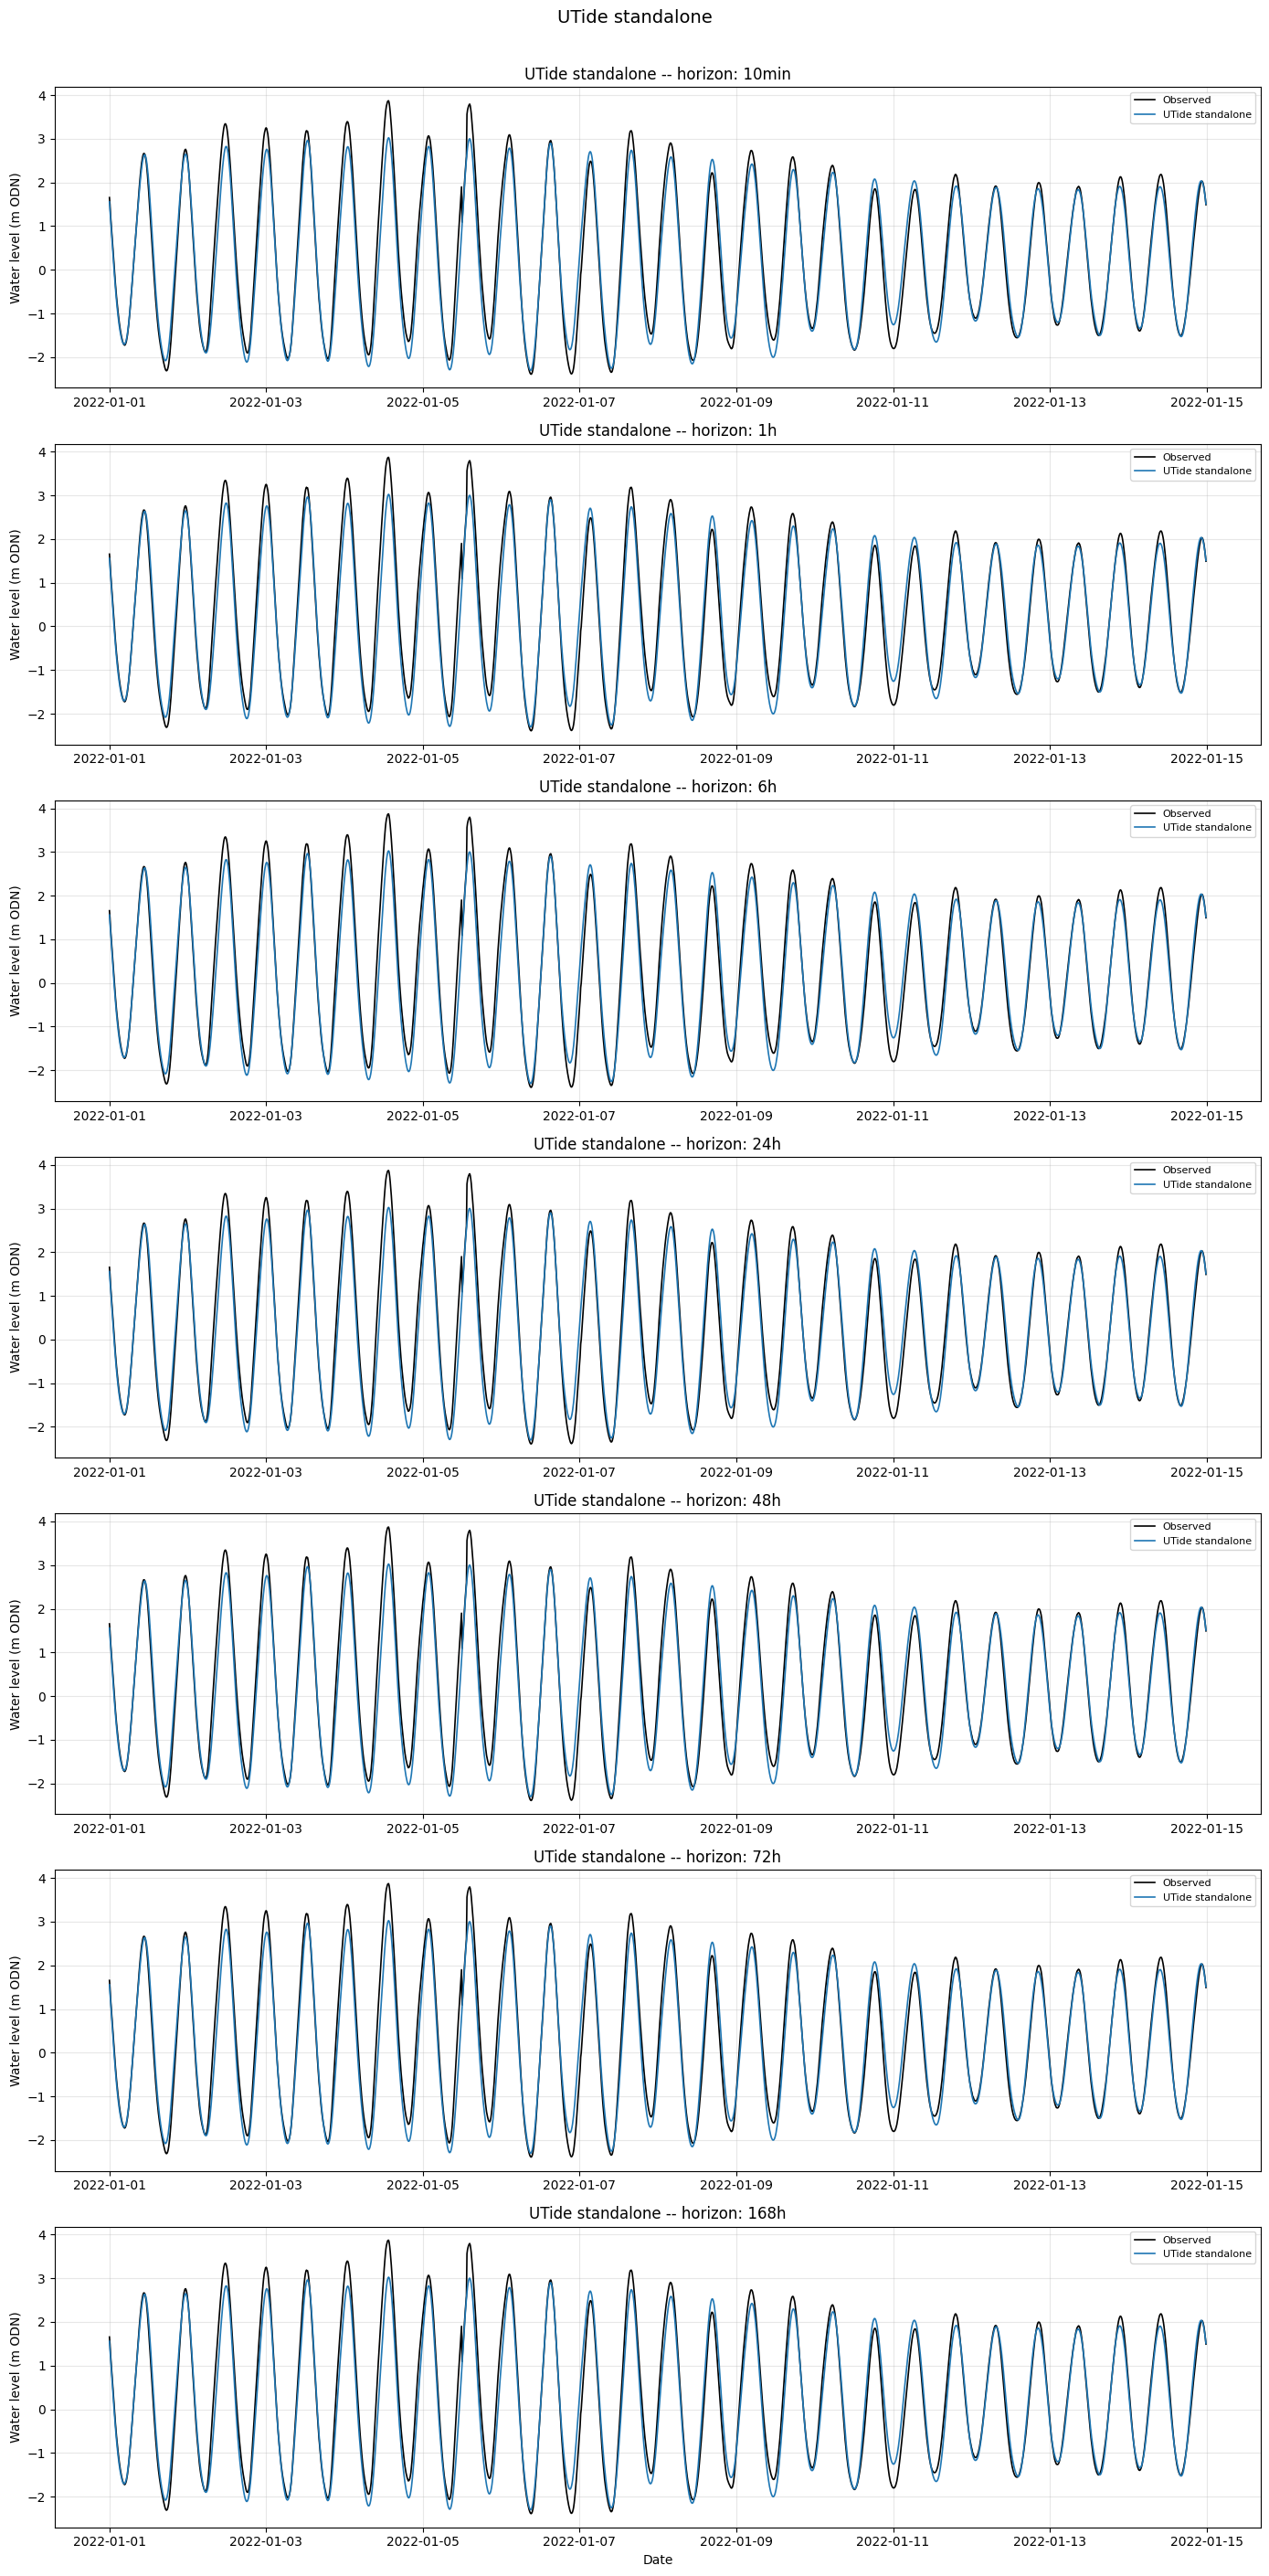

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_utide_standalone.png


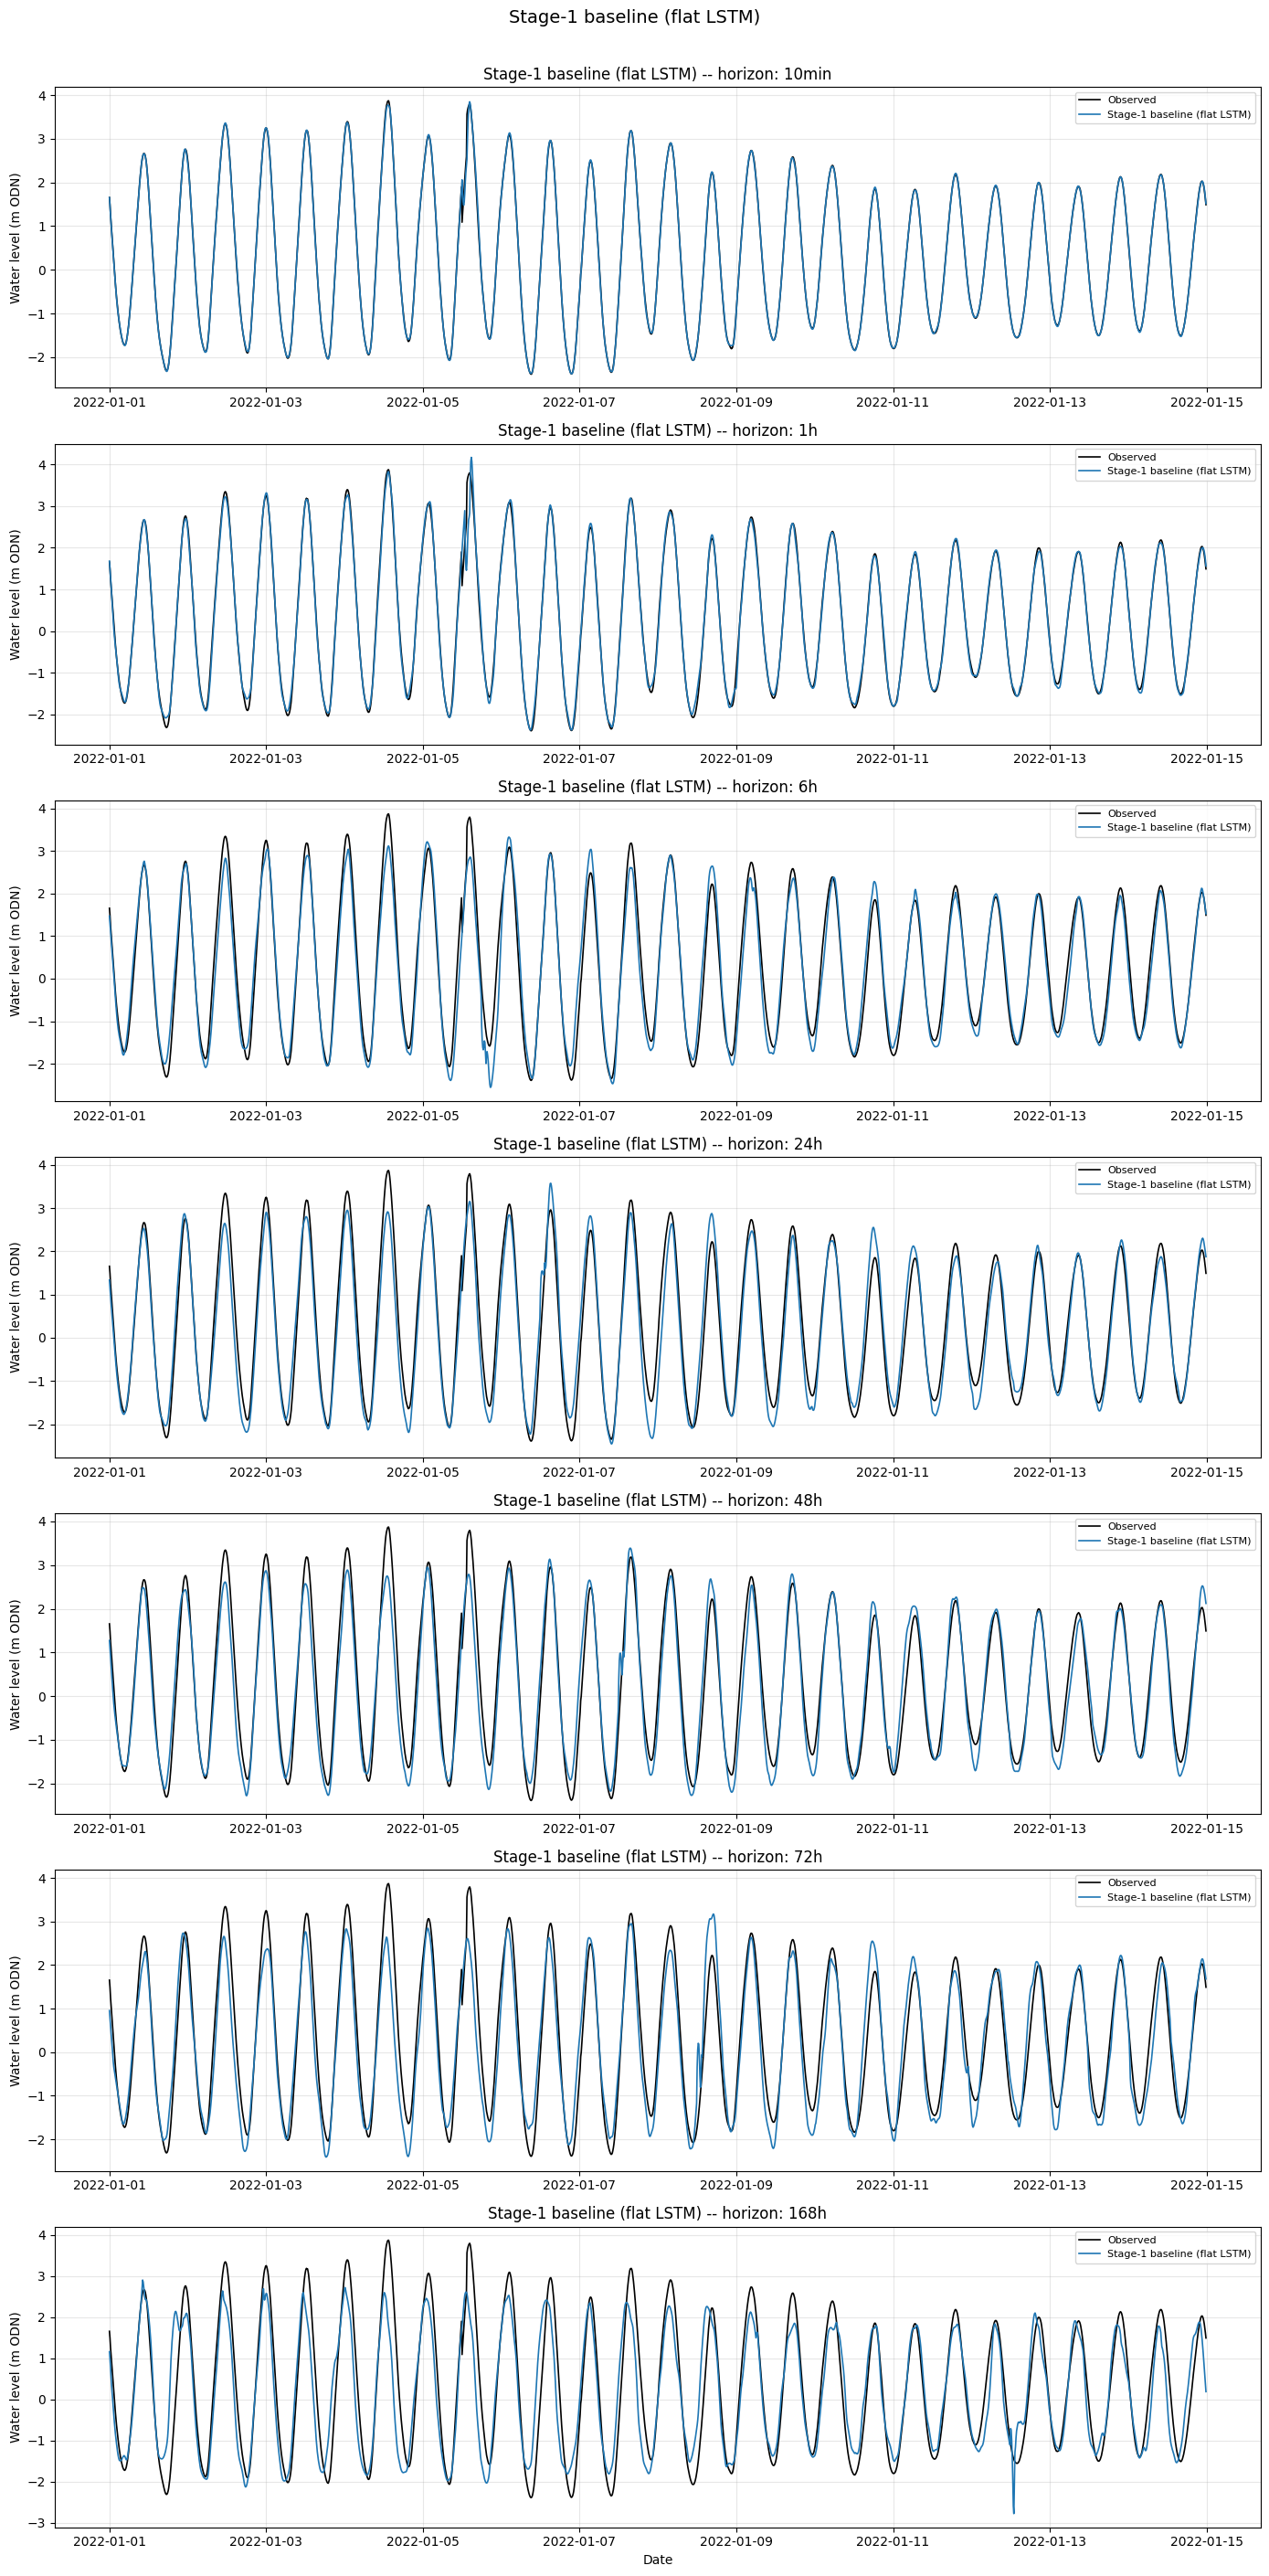

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_stage-1_baseline_flat_lstm.png


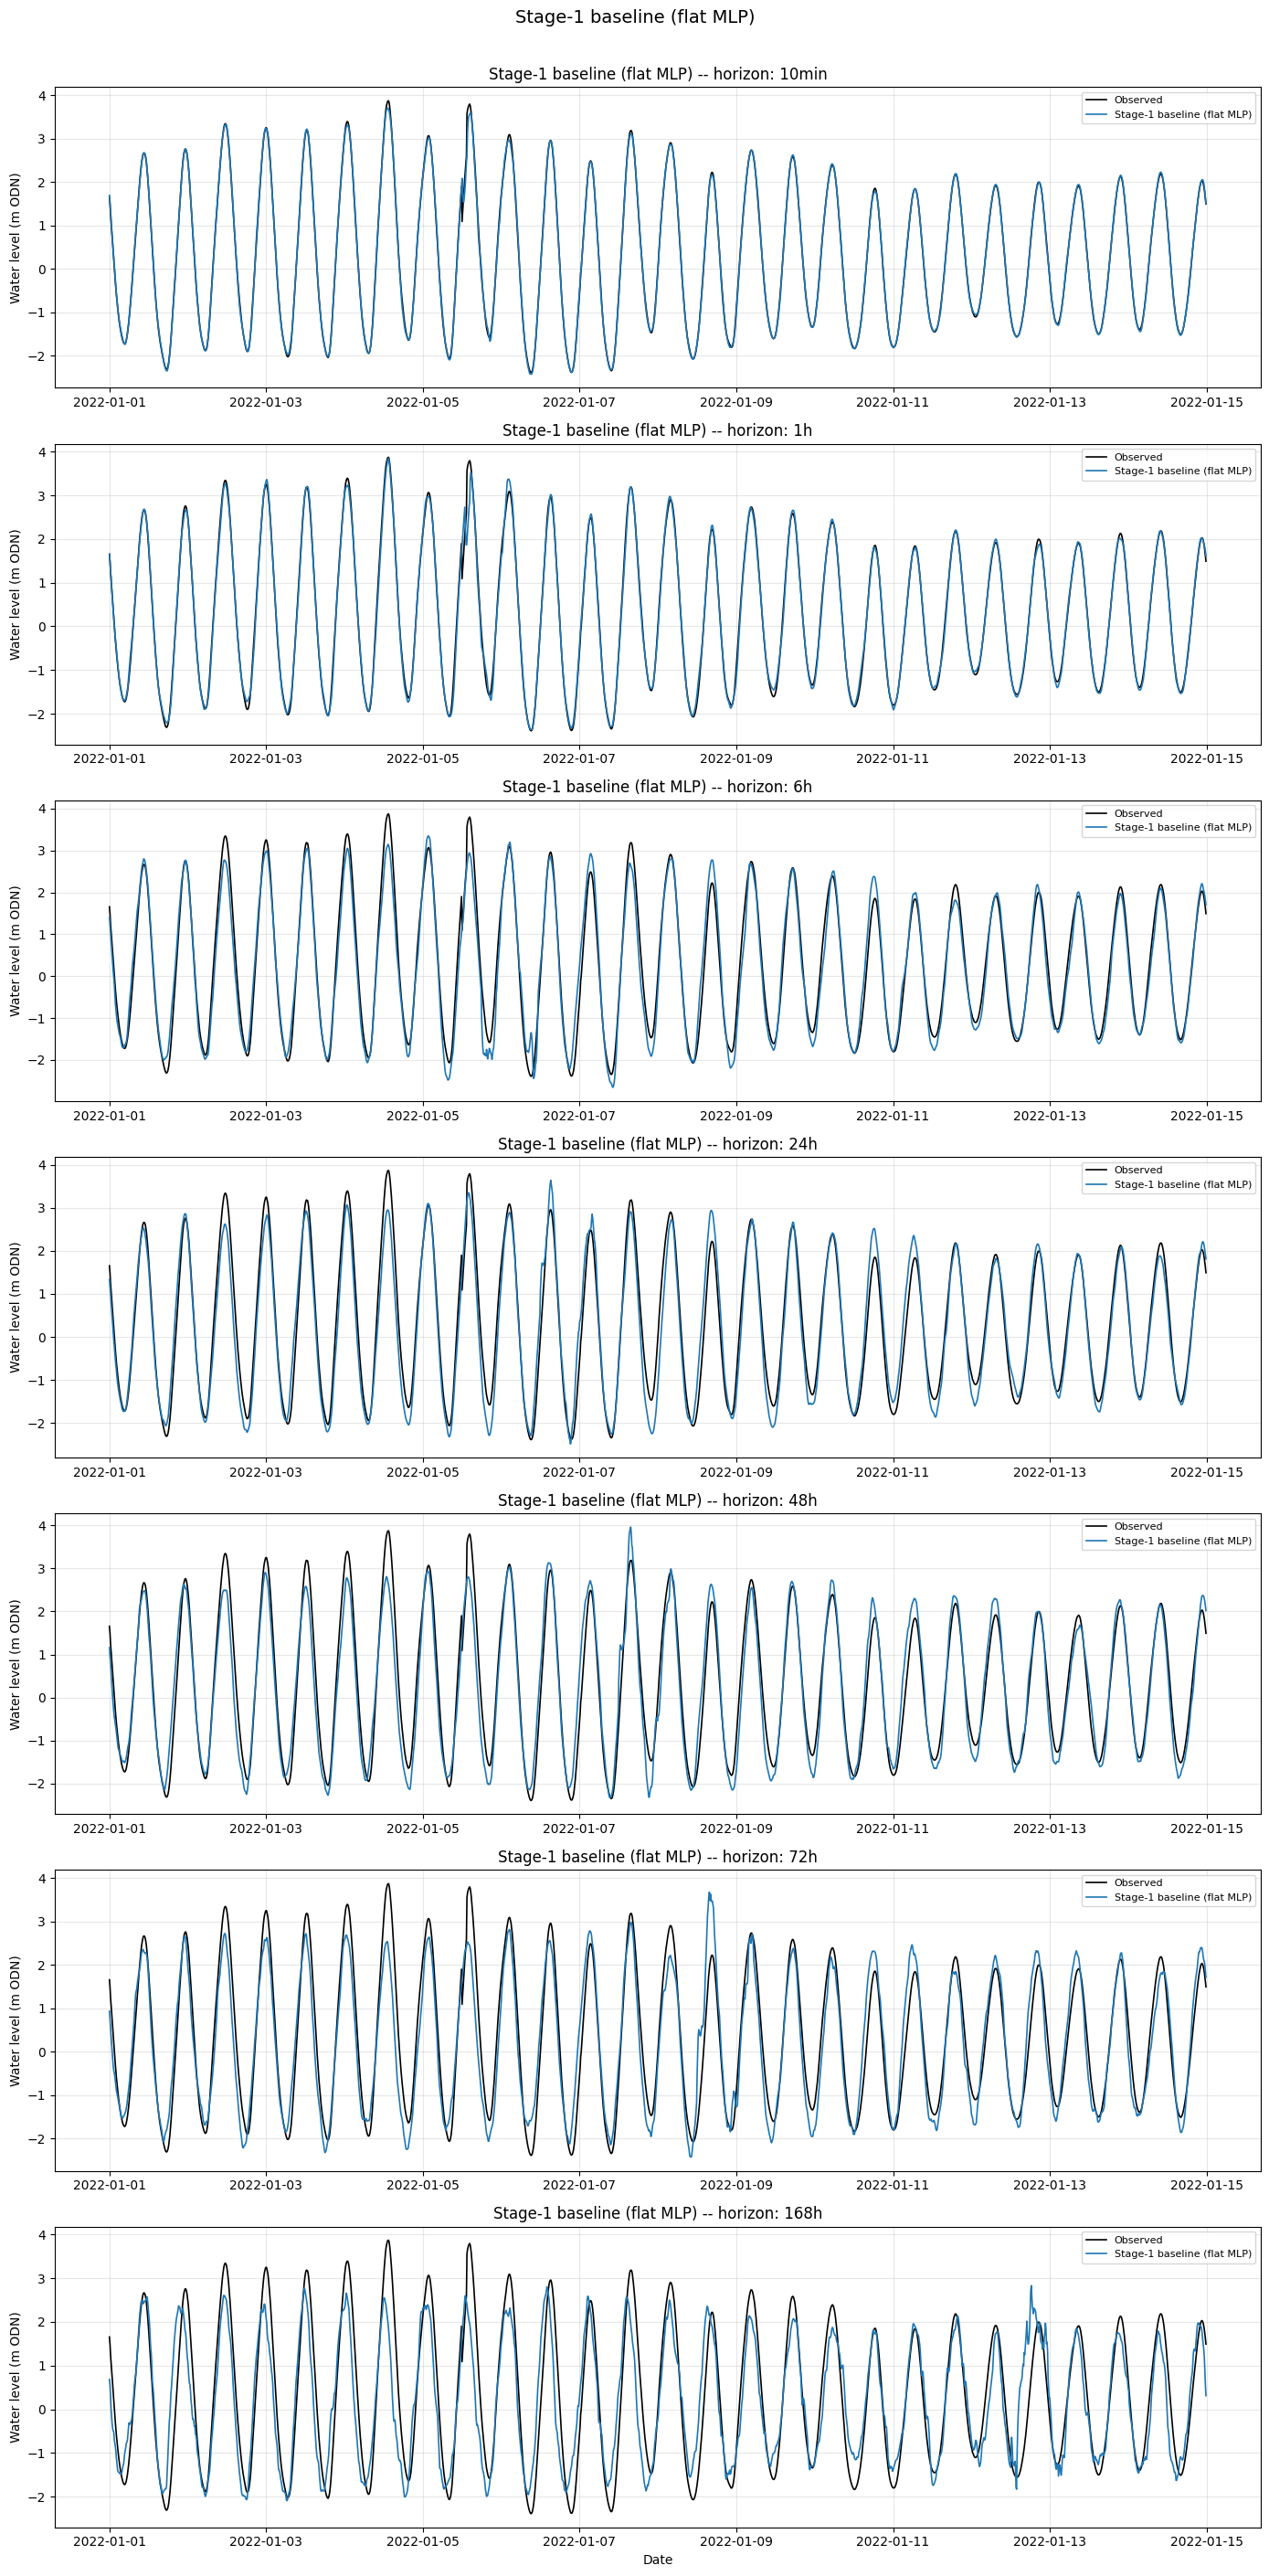

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_stage-1_baseline_flat_mlp.png


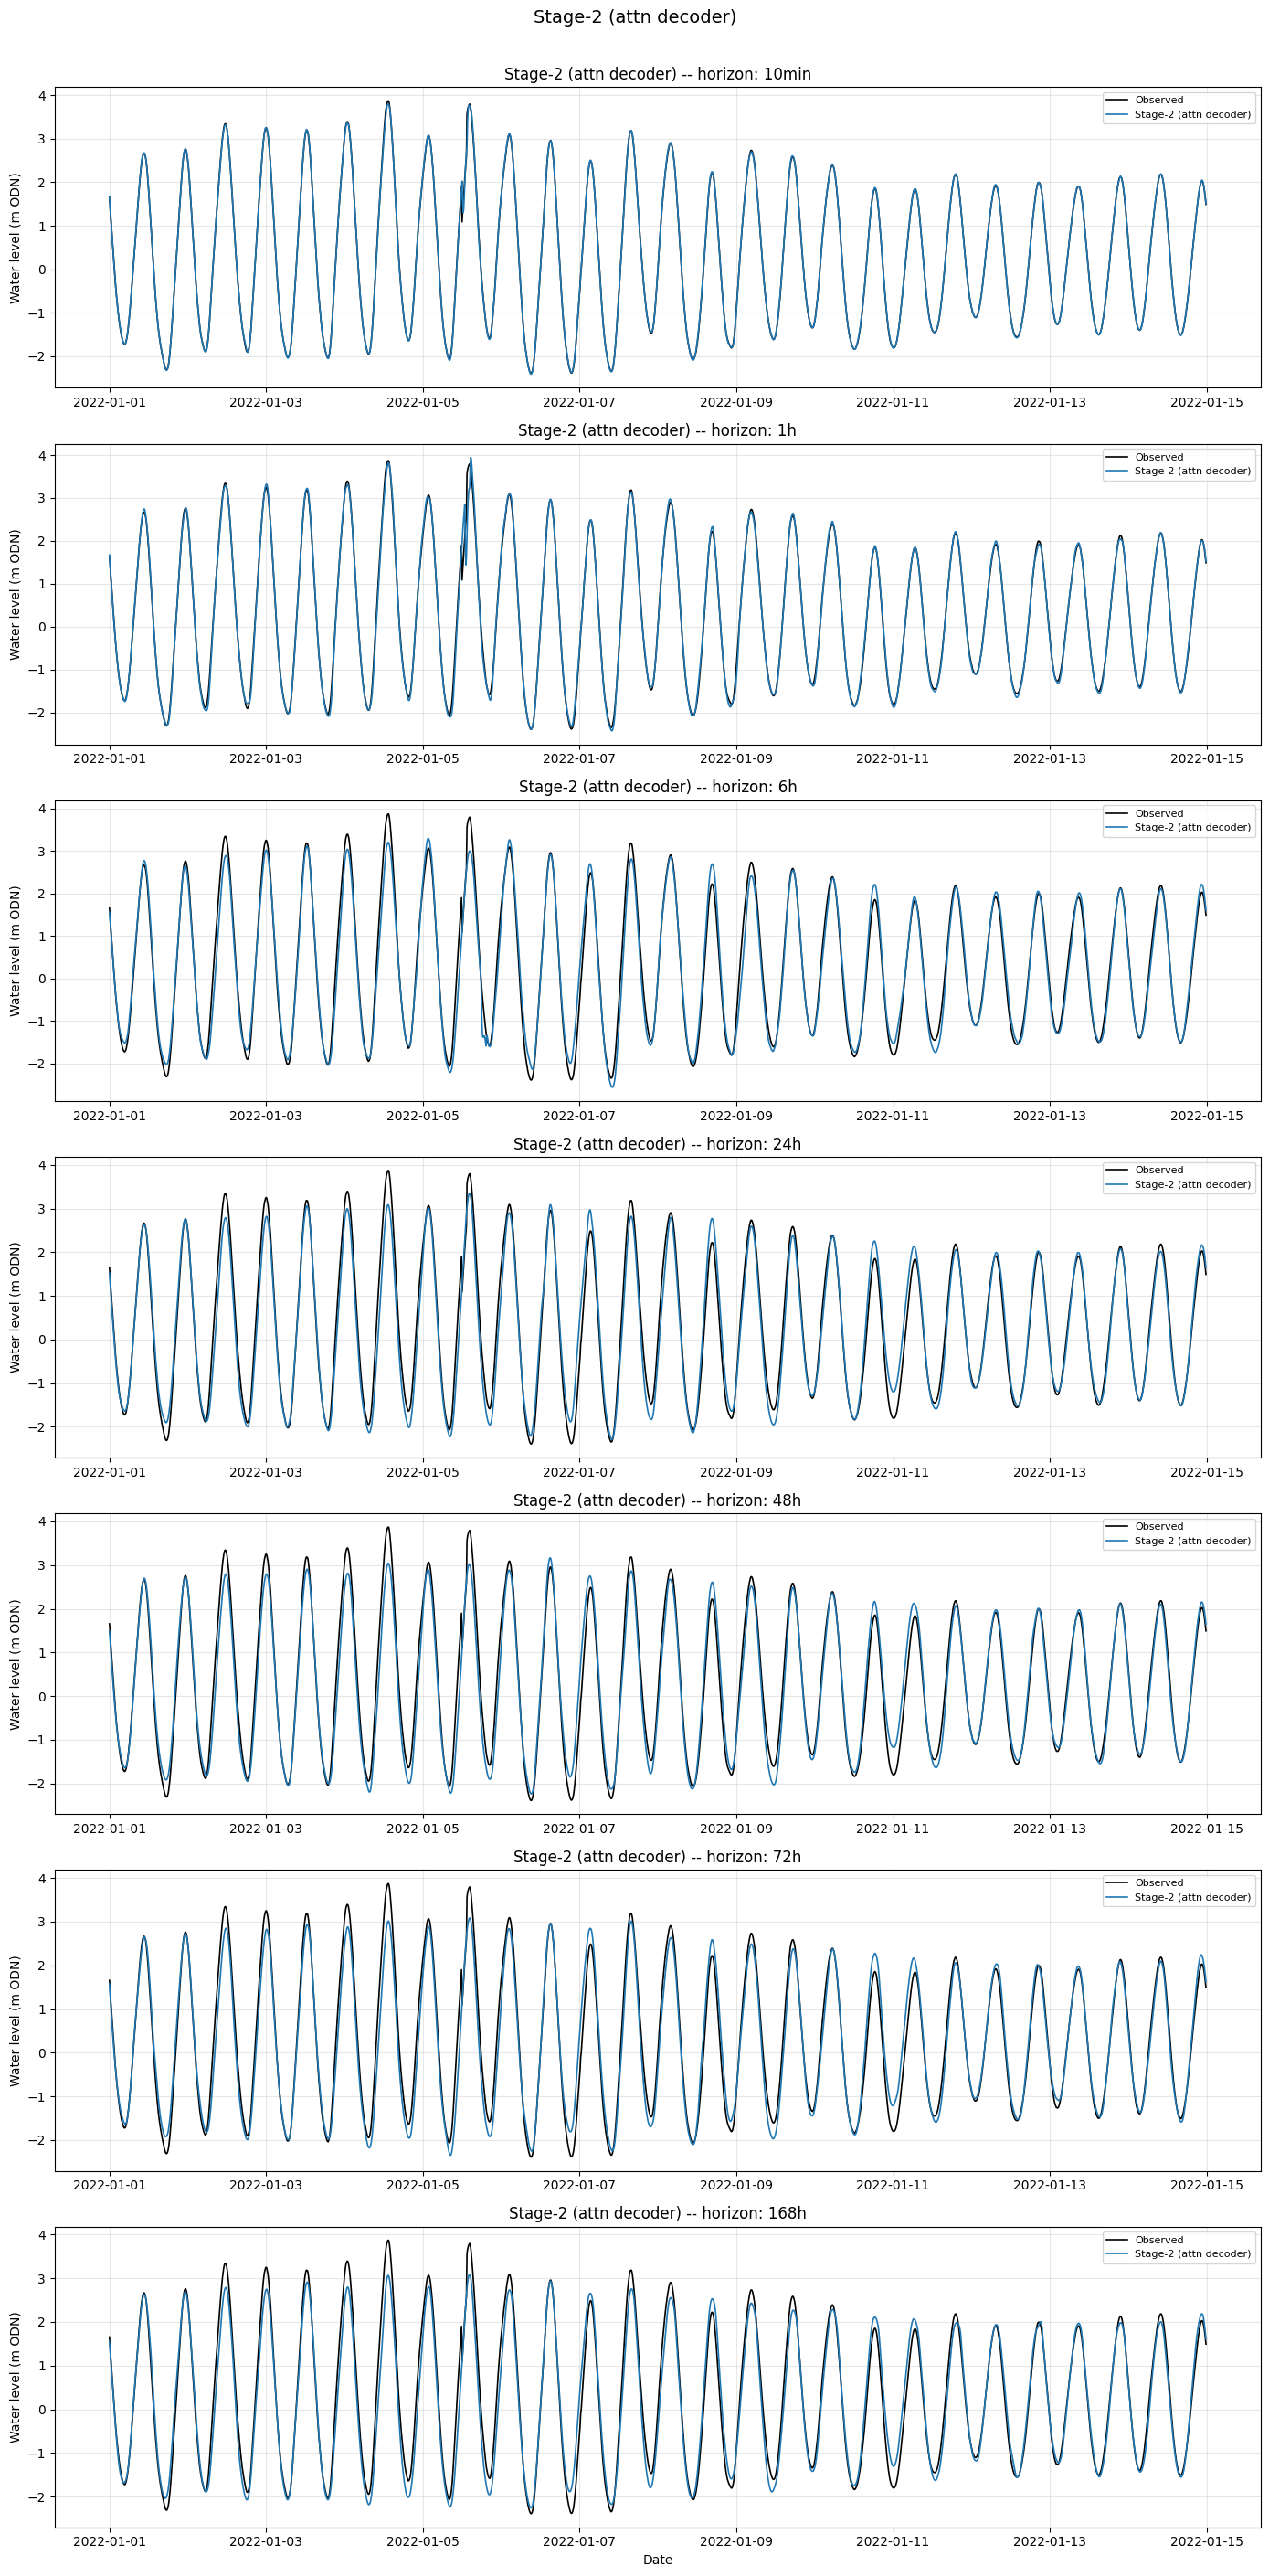

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_stage-2_attn_decoder.png


In [28]:
window_start = pd.Timestamp('2022-01-01')
window_end = window_start + pd.Timedelta(days=14)

model_preds_by_horizon = {
    'Naive persistence': naive_test,
    'Tide-aware persistence': tide_pers_test,
    'UTide standalone': utide_baseline,
    'Stage-1 baseline (flat LSTM)': test_preds_s1_lstm,
    'Stage-1 baseline (flat MLP)': test_preds_s1_mlp,
    'Stage-2 (attn decoder)': test_preds_s2,
}


def sanitize_name(name):
    return name.lower().replace(' ', '_').replace('(', '').replace(')', '')


rollout_plot_paths = {}
for name, preds in model_preds_by_horizon.items():
    fig, axes = plt.subplots(N_HORIZONS, 1, figsize=(14, 4 * N_HORIZONS), sharex=False)
    for j, (hname, ax) in enumerate(zip(HORIZON_NAMES, axes)):
        target_times = Time_test[:, j]
        plot_mask = (target_times >= np.datetime64(window_start)) & (target_times < np.datetime64(window_end))

        ax.plot(target_times[plot_mask], Y_test[plot_mask, j], label='Observed', color='black', linewidth=1.2)
        ax.plot(target_times[plot_mask], preds[plot_mask, j], label=name, color='tab:blue', linewidth=1.2)

        ax.set_title(f'{name} -- horizon: {hname}')
        ax.set_ylabel('Water level (m ODN)')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel('Date')
    plt.suptitle(name, y=1.005, fontsize=14)
    plt.tight_layout()

    path = os.path.join(OUTPUT_DIR, f'stage2_rollout_{sanitize_name(name)}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    rollout_plot_paths[name] = path
    print(f"saved {path}")


## 12. Save outputs to Google Drive

In [29]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'stage2_tidal_seq2seq.pt')
torch.save({
    'model_state_dict': stage2_model.state_dict(),
    'config': {
        'enc_hidden_size': ENC_HIDDEN_SIZE,
        'enc_num_layers': ENC_NUM_LAYERS,
        'dec_hidden_size': DEC_HIDDEN_SIZE,
        'dec_num_layers': DEC_NUM_LAYERS,
        'attn_dim': ATTN_DIM,
        'lookback': LOOKBACK,
        'horizons': HORIZONS,
    },
    'scaler': {'mean': train_mean, 'std': train_std},
}, checkpoint_path)

stage1_lstm_checkpoint_path = os.path.join(OUTPUT_DIR, 'stage1_flat_lstm_multihorizon.pt')
torch.save({
    'model_state_dict': stage1_lstm_model.state_dict(),
    'config': {
        'hidden_size': ENC_HIDDEN_SIZE,
        'num_layers': ENC_NUM_LAYERS,
        'lookback': LOOKBACK,
        'horizons': HORIZONS,
    },
    'scaler': {'mean': train_mean, 'std': train_std},
}, stage1_lstm_checkpoint_path)

stage1_mlp_checkpoint_path = os.path.join(OUTPUT_DIR, 'stage1_flat_mlp_multihorizon.pt')
torch.save({
    'model_state_dict': stage1_mlp_model.state_dict(),
    'config': {
        'hidden': (128, 64),
        'lookback': LOOKBACK,
        'horizons': HORIZONS,
    },
    'scaler': {'mean': train_mean, 'std': train_std},
}, stage1_mlp_checkpoint_path)

print(f"saved {checkpoint_path}")
print(f"saved {stage1_lstm_checkpoint_path}")
print(f"saved {stage1_mlp_checkpoint_path}")
print(f"saved {metrics_path}")
print(f"saved {combined_loss_curve_path}")
print(f"saved {loss_curve_path}")
print(f"saved {rmse_curve_path}")
for name, path in rollout_plot_paths.items():
    print(f"saved {path}")
print(f"\nAll stage-2 outputs are under: {OUTPUT_DIR}")


saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_tidal_seq2seq.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage1_flat_lstm_multihorizon.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage1_flat_mlp_multihorizon.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_metrics.csv
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_loss_curves_combined.png
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_loss_curves.png
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_vs_horizon.png
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_naive_persistence.png
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_tide-aware_persistence.png
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2

## 13. Next steps

- Add meteorological covariates (pressure, discharge, rainfall, wind) as
  additional encoder/decoder inputs -- the next stage.
- Sweep decoder hidden size, number of layers, and attention dimension
  (kept modest and untuned here).
- Inspect attention weights (returned alongside predictions by
  `TidalSeq2Seq.forward`) to see which parts of the 96-step history the
  model leans on at each horizon -- e.g. does the 48h-ahead prediction
  attend to a different part of the tidal cycle than the 10-min one?
- Check performance specifically around storm surge periods once the test
  window covers one.


## 14. Robustness checks (pre-next-stage sanity tests)

Before moving on to the meteorological-covariate stage, three checks to make sure the story
told by sections 9-11 actually holds up:

- **14.1 -- Tide-input ablation.** Section 10's Stage-1-vs-Stage-2 comparison changes the
  architecture *and* adds the UTide decoder input at the same time, so it can't say how much
  of the improvement is the tidal input itself. Here the exact same `TidalSeq2Seq` architecture
  is retrained with the decoder input zeroed out, isolating just the tidal signal's contribution.
- **14.2 -- Forecast accuracy later in the test window.** All of section 10's numbers are
  averaged across the whole 2021-2024 test period. This checks whether accuracy holds up as the
  forecast target gets further from the 2018 training cutoff -- e.g. a week in 2024 vs. a week
  right at the start of the test period.
- **14.3 -- Sensitivity to training-data volume.** Retrains the Stage-2 model on the last 3, 7,
  and 10 years of history (instead of all 14) to see where -- if anywhere -- there's a cliff in
  performance, which matters for how much historical data future gauges/stages actually need.

14.1 and 14.3 each train one or more fresh models with the same hyperparameters as section 9,
so this section takes at least as long as the rest of the notebook combined on a T4 -- run it as
one long session rather than cell-by-cell.

### 14.1 Isolating the tidal input's contribution

Retrains `TidalSeq2Seq` with the same hyperparameters, on the same `train_tensors_seq2seq` /
`val_tensors_seq2seq` data as `stage2_model` in section 9c, but with the decoder always fed
zeros in place of the UTide reconstruction (`torch.zeros_like(batch['Ydec'])`). Same weights
shape, same attention, same everything else -- the only thing that changes is whether the
decoder ever sees tidal information, so any RMSE gap versus `stage2_model` is attributable to
that input alone, rather than to the architecture change baked into the section 9-10
Stage-1/Stage-2 comparison.

In [30]:
predict_seq2seq_notide = lambda model, batch: model(batch['X'], torch.zeros_like(batch['Ydec']))[0]

set_seed()
stage2_notide_model = TidalSeq2Seq(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ATTN_DIM).to(device)
stage2_notide_model, stage2_notide_history = train_model(
    stage2_notide_model, predict_seq2seq_notide, train_tensors_seq2seq, val_tensors_seq2seq,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage2-no-tide-ablation',
)

rmse_notide, mae_notide, test_preds_notide = compute_metrics(
    stage2_notide_model, predict_seq2seq_notide, test_tensors_seq2seq, Y_test, Flag_test)

[stage2-no-tide-ablation] epoch 001  train_loss=0.21587  val_loss=0.09291  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 002  train_loss=0.08895  val_loss=0.08749  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 003  train_loss=0.08491  val_loss=0.08409  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 004  train_loss=0.08214  val_loss=0.08015  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 005  train_loss=0.07960  val_loss=0.08011  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 006  train_loss=0.07746  val_loss=0.07526  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 007  train_loss=0.07552  val_loss=0.07518  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 008  train_loss=0.07439  val_loss=0.07440  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 009  train_loss=0.07292  val_loss=0.07186  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 010  train_loss=0.07186  val_loss=0.07254  lr=1.0e-03
[stage2-no-tide-ablation] epoch 011  train_loss=0.07084  val_loss=0.06993  lr=1.0e-03  *
[stage2-no-tide-ablation

In [31]:
ablation_results = []
rmse_naive_a, mae_naive_a = masked_rmse_mae(naive_test, Y_test, Flag_test)
rmse_tp_a, mae_tp_a = masked_rmse_mae(tide_pers_test, Y_test, Flag_test)
rmse_utide_a, mae_utide_a = masked_rmse_mae(utide_baseline, Y_test, Flag_test)

for j, hname in enumerate(HORIZON_NAMES):
    ablation_results.append({'model': 'Naive persistence', 'horizon': hname, 'rmse_m': rmse_naive_a[j], 'mae_m': mae_naive_a[j]})
    ablation_results.append({'model': 'Tide-aware persistence', 'horizon': hname, 'rmse_m': rmse_tp_a[j], 'mae_m': mae_tp_a[j]})
    ablation_results.append({'model': 'UTide standalone', 'horizon': hname, 'rmse_m': rmse_utide_a[j], 'mae_m': mae_utide_a[j]})
    ablation_results.append({'model': 'Stage-2 (with tide)', 'horizon': hname, 'rmse_m': rmse_s2[j], 'mae_m': mae_s2[j]})
    ablation_results.append({'model': 'Stage-2 (no tide, ablation)', 'horizon': hname, 'rmse_m': rmse_notide[j], 'mae_m': mae_notide[j]})

ablation_df = pd.DataFrame(ablation_results)
ablation_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_ablation_metrics.csv')
ablation_df.to_csv(ablation_metrics_path, index=False)
print(f"saved {ablation_metrics_path}")

ablation_pivot = ablation_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES]
ablation_pivot = ablation_pivot.loc[['Naive persistence', 'Tide-aware persistence', 'UTide standalone',
                                      'Stage-2 (no tide, ablation)', 'Stage-2 (with tide)']]
ablation_pivot.round(4)

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_ablation_metrics.csv


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1329,0.7859,3.0826,0.7156,1.2962,1.8294,2.9235
Tide-aware persistence,0.4381,0.4379,0.4377,0.3802,0.5249,0.6975,1.1185
UTide standalone,0.2454,0.2454,0.2453,0.2445,0.2439,0.2438,0.2456
"Stage-2 (no tide, ablation)",0.0232,0.0576,0.2436,0.2984,0.3835,0.4940,0.7719
Stage-2 (with tide),0.0173,0.0519,0.1882,0.2230,0.2260,0.2284,0.2347


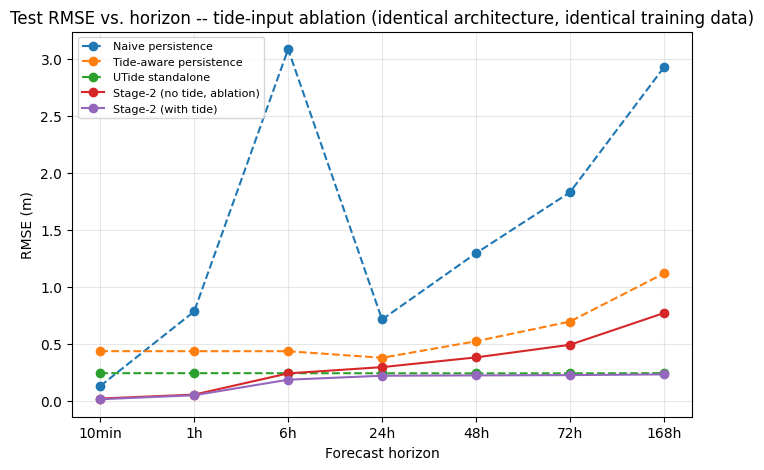

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_ablation_rmse_vs_horizon.png
   10min: removing the tidal input increases RMSE by 25.6%
      1h: removing the tidal input increases RMSE by 9.9%
      6h: removing the tidal input increases RMSE by 22.7%
     24h: removing the tidal input increases RMSE by 25.3%
     48h: removing the tidal input increases RMSE by 41.1%
     72h: removing the tidal input increases RMSE by 53.8%
    168h: removing the tidal input increases RMSE by 69.6%


In [32]:
plt.figure(figsize=(8, 5))
for name in ablation_pivot.index:
    style = '--' if name in ('Naive persistence', 'Tide-aware persistence', 'UTide standalone') else '-'
    plt.plot(HORIZON_NAMES, ablation_pivot.loc[name], marker='o', linestyle=style, label=name)
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE (m)')
plt.title('Test RMSE vs. horizon -- tide-input ablation (identical architecture, identical training data)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
ablation_plot_path = os.path.join(OUTPUT_DIR, 'stage2_ablation_rmse_vs_horizon.png')
plt.savefig(ablation_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {ablation_plot_path}")

tide_contribution_pct = 100 * (rmse_notide - rmse_s2) / rmse_notide
for h, pct in zip(HORIZON_NAMES, tide_contribution_pct):
    print(f"  {h:>6s}: removing the tidal input increases RMSE by {pct:.1f}%")

### 14.2 Forecast accuracy later in the test window

No retraining here -- `stage2_model`'s predictions (`test_preds_s2`) already span the whole
2021-2024 test period at every horizon. This just slices those predictions by calendar year,
and by specific weeks, to see whether accuracy holds up as the forecast target moves further
from the 2018 training cutoff -- i.e. whether this model (and its UTide decoder input) would
still be trustworthy if left running for years without retraining.

In [33]:
year_rows = []
years_present = sorted(pd.DatetimeIndex(Time_test[:, 0]).year.unique())
for yr in years_present:
    for j, hname in enumerate(HORIZON_NAMES):
        t = pd.DatetimeIndex(Time_test[:, j])
        yr_mask = t.year == yr
        if yr_mask.sum() == 0:
            continue
        err = test_preds_s2[yr_mask, j] - Y_test[yr_mask, j]
        flg = Flag_test[yr_mask, j]
        err = err[~flg]
        year_rows.append({'year': yr, 'horizon': hname, 'rmse_m': float(np.sqrt(np.mean(err ** 2))), 'n': len(err)})

year_df = pd.DataFrame(year_rows)
year_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_rmse_by_calendar_year.csv')
year_df.to_csv(year_metrics_path, index=False)
print(f"saved {year_metrics_path}")

year_pivot = year_df.pivot(index='year', columns='horizon', values='rmse_m')[HORIZON_NAMES]
year_pivot.round(4)

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_by_calendar_year.csv


horizon,10min,1h,6h,24h,48h,72h,168h
year,,,,,,,
2021,0.0168,0.0486,0.1772,0.2132,0.2169,0.2185,0.2235
2022,0.0194,0.0593,0.1995,0.2360,0.2359,0.2390,0.2430
2023,0.0157,0.0486,0.1842,0.2182,0.2216,0.2231,0.2263
2024,0.0169,0.0503,0.1917,0.2241,0.2292,0.2328,0.2454


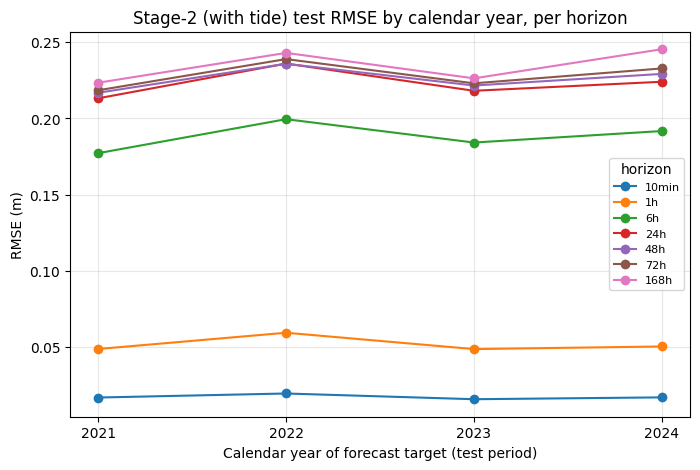

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_by_calendar_year.png


In [34]:
plt.figure(figsize=(8, 5))
for hname in HORIZON_NAMES:
    plt.plot(year_pivot.index, year_pivot[hname], marker='o', label=hname)
plt.xlabel('Calendar year of forecast target (test period)')
plt.ylabel('RMSE (m)')
plt.title('Stage-2 (with tide) test RMSE by calendar year, per horizon')
plt.legend(title='horizon', fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(year_pivot.index)
year_plot_path = os.path.join(OUTPUT_DIR, 'stage2_rmse_by_calendar_year.png')
plt.savefig(year_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {year_plot_path}")

In [35]:
def week_metrics(week_start, label, preds=test_preds_s2):
    week_start = pd.Timestamp(week_start)
    week_end = week_start + pd.Timedelta(days=7)
    rows = []
    for j, hname in enumerate(HORIZON_NAMES):
        t = pd.DatetimeIndex(Time_test[:, j])
        mask = (t >= week_start) & (t < week_end)
        if mask.sum() == 0:
            continue
        err = preds[mask, j] - Y_test[mask, j]
        flg = Flag_test[mask, j]
        err = err[~flg]
        rows.append({'week': label, 'horizon': hname, 'rmse_m': float(np.sqrt(np.mean(err ** 2))), 'n': len(err)})
    return rows


week_starts = {
    '2021-W1 (start of test)': '2021-01-01',
    '2022-W1': '2022-01-01',
    '2024-W1 (3yr into test)': '2024-01-01',
}
week_rows = []
for label, start in week_starts.items():
    week_rows += week_metrics(start, label)

week_df = pd.DataFrame(week_rows)
week_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_rmse_by_test_week.csv')
week_df.to_csv(week_metrics_path, index=False)
print(f"saved {week_metrics_path}")

week_pivot = week_df.pivot(index='week', columns='horizon', values='rmse_m')[HORIZON_NAMES]
week_pivot.round(4)

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_by_test_week.csv


horizon,10min,1h,6h,24h,48h,72h,168h
week,,,,,,,
2021-W1 (start of test),0.0127,0.0420,0.1064,0.0969,0.1064,0.0943,NaN
2022-W1,0.0361,0.1050,0.3180,0.3908,0.3984,0.4011,0.4048
2024-W1 (3yr into test),0.0169,0.0546,0.1604,0.1539,0.1530,0.1646,0.1804


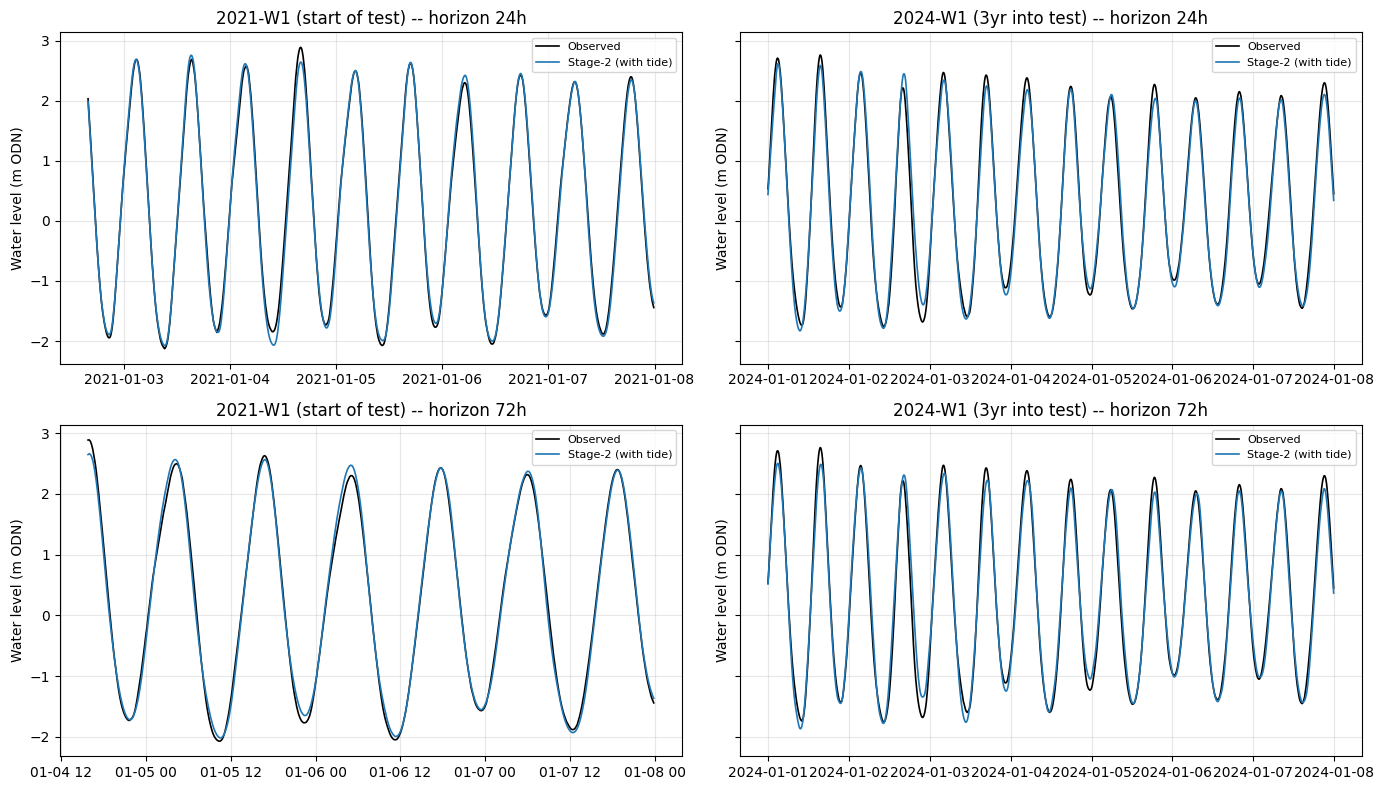

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rollout_early_vs_late_test_weeks.png


In [36]:
plot_horizons = ['24h', '72h']
fig, axes = plt.subplots(len(plot_horizons), 2, figsize=(14, 4 * len(plot_horizons)), sharey='row')
compare_weeks = [('2021-W1 (start of test)', '2021-01-01'), ('2024-W1 (3yr into test)', '2024-01-01')]
for row, hname in enumerate(plot_horizons):
    j = HORIZON_NAMES.index(hname)
    for col, (label, start) in enumerate(compare_weeks):
        ws = pd.Timestamp(start)
        we = ws + pd.Timedelta(days=7)
        t = pd.DatetimeIndex(Time_test[:, j])
        mask = (t >= ws) & (t < we)
        ax = axes[row, col]
        ax.plot(t[mask], Y_test[mask, j], label='Observed', color='black', linewidth=1.2)
        ax.plot(t[mask], test_preds_s2[mask, j], label='Stage-2 (with tide)', color='tab:blue', linewidth=1.2)
        ax.set_title(f'{label} -- horizon {hname}')
        ax.set_ylabel('Water level (m ODN)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
plt.tight_layout()
weeks_plot_path = os.path.join(OUTPUT_DIR, 'stage2_rollout_early_vs_late_test_weeks.png')
plt.savefig(weeks_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {weeks_plot_path}")

### 14.3 Sensitivity to training-data volume

Train end stays fixed at 2018-01-01 and validation/test stay exactly as in sections 4/10
(2018-2021 / 2021-2024) -- only the *start* of the training window moves: 2015 (3yr), 2011
(7yr), 2008 (10yr), vs. the full 2004-2018 (14yr) used everywhere else in this notebook. UTide
is refit separately for each window -- with less history its own constituent estimates degrade
too, so tracking `reduced_utide_only` alongside the retrained `TidalSeq2Seq` models separates
"the neural net has less to learn from" from "the tidal input it's given is itself worse." The
14-year row reuses `stage2_model` / `test_preds_s2` from section 9c-10 directly, so it isn't
retrained again here.

In [37]:
REDUCED_TRAIN_STARTS = {'3yr': '2015-01-01', '7yr': '2011-01-01', '10yr': '2008-01-01'}


def refit_utide_recon(train_start, train_end):
    mask = (df['DateTime'] >= train_start) & (df['DateTime'] < train_end)
    fit_series = df.loc[mask, 'Observed_ODN'].copy()
    fit_series[df.loc[mask, 'is_flagged']] = np.nan
    coef = utide.solve(df.loc[mask, 'DateTime'], fit_series, lat=SITE_LAT, method='ols', conf_int='none')
    recon = utide.reconstruct(pd.DatetimeIndex(df['DateTime']), coef, min_SNR=0, min_PE=0, verbose=False)
    return np.asarray(recon['h'], dtype=np.float32)


def prepare_reduced_scenario(name, train_start):
    recon = refit_utide_recon(train_start, TRAIN_END)
    scen_df = df.copy()
    scen_df['utide_recon'] = recon

    tr_df = scen_df[(scen_df['DateTime'] >= train_start) & (scen_df['DateTime'] < TRAIN_END)].reset_index(drop=True)
    va_df = scen_df[(scen_df['DateTime'] >= TRAIN_END) & (scen_df['DateTime'] < VAL_END)].reset_index(drop=True)
    te_df = scen_df[scen_df['DateTime'] >= VAL_END].reset_index(drop=True)

    Xtr, Ydtr, Ytr, Ftr, _ = build_windows_multi(tr_df, LOOKBACK, HORIZON_STEPS)
    Xva, Ydva, Yva, Fva, _ = build_windows_multi(va_df, LOOKBACK, HORIZON_STEPS)
    Xte, Ydte, Yte, Fte, _ = build_windows_multi(te_df, LOOKBACK, HORIZON_STEPS)

    Xtr, Ydtr, Ytr, Ftr = Xtr[::TRAIN_STRIDE], Ydtr[::TRAIN_STRIDE], Ytr[::TRAIN_STRIDE], Ftr[::TRAIN_STRIDE]

    mean_ = float(tr_df['Observed_ODN'].mean())
    std_ = float(tr_df['Observed_ODN'].std())

    def sc(a):
        return (a - mean_) / std_

    def tt(a, dtype=torch.float32):
        return torch.tensor(a, dtype=dtype, device=device)

    train_tensors = {'X': tt(sc(Xtr)), 'Ydec': tt(sc(Ydtr)), 'Y': tt(sc(Ytr)), 'Flag': tt(Ftr, dtype=torch.bool)}
    val_tensors = {'X': tt(sc(Xva)), 'Ydec': tt(sc(Ydva)), 'Y': tt(sc(Yva)), 'Flag': tt(Fva, dtype=torch.bool)}
    test_tensors = {'X': tt(sc(Xte)), 'Ydec': tt(sc(Ydte))}

    print(f"[{name}] train {tr_df.DateTime.min().date()} -> {tr_df.DateTime.max().date()} "
          f"({Xtr.shape[0]:,} windows, stride {TRAIN_STRIDE})  val {Xva.shape[0]:,}  test {Xte.shape[0]:,}")

    return {
        'name': name, 'mean': mean_, 'std': std_,
        'train_tensors': train_tensors, 'val_tensors': val_tensors, 'test_tensors': test_tensors,
        'Y_test': Yte, 'Flag_test': Fte, 'Ydec_test': Ydte,
    }


@torch.no_grad()
def compute_metrics_scaled(model, predict_fn, tensors, y_raw, flagged, mean_, std_, batch_size=4096):
    # Same as compute_metrics, but takes the scaler explicitly instead of closing over the
    # notebook-global train_mean/train_std -- each reduced-training-window scenario below has
    # its own mean/std, computed from only the data that scenario was allowed to see.
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k not in ('Y', 'Flag')}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * std_ + mean_
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae, preds_m

In [38]:
reduced_results = []
reduced_utide_only = []
stage2_reduced_models = {}
stage2_reduced_scenarios = {}

reduced_results += [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_s2[j], 'mae_m': mae_s2[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]
rmse_u14, mae_u14 = masked_rmse_mae(utide_baseline, Y_test, Flag_test)
reduced_utide_only += [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_u14[j], 'mae_m': mae_u14[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]

for name, start in REDUCED_TRAIN_STARTS.items():
    n_years = int(name.replace('yr', ''))
    scen = prepare_reduced_scenario(name, start)
    stage2_reduced_scenarios[name] = scen

    rmse_u, mae_u = masked_rmse_mae(scen['Ydec_test'], scen['Y_test'], scen['Flag_test'])
    reduced_utide_only += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_u[j], 'mae_m': mae_u[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

    set_seed()
    m = TidalSeq2Seq(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ATTN_DIM).to(device)
    m, _ = train_model(
        m, predict_seq2seq, scen['train_tensors'], scen['val_tensors'],
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label=f'stage2-{name}',
    )
    stage2_reduced_models[name] = m

    rmse_r, mae_r, _ = compute_metrics_scaled(
        m, predict_seq2seq, scen['test_tensors'], scen['Y_test'], scen['Flag_test'], scen['mean'], scen['std'])
    reduced_results += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_r[j], 'mae_m': mae_r[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

reduced_df = pd.DataFrame(reduced_results)
reduced_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_reduced_training_data_metrics.csv')
reduced_df.to_csv(reduced_metrics_path, index=False)
print(f"saved {reduced_metrics_path}")

utide_only_df = pd.DataFrame(reduced_utide_only)
utide_only_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_reduced_training_utide_only_metrics.csv')
utide_only_df.to_csv(utide_only_metrics_path, index=False)
print(f"saved {utide_only_metrics_path}")

train_years_order = reduced_df.drop_duplicates('model').set_index('model')['train_years'].sort_values()
reduced_pivot = reduced_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].loc[train_years_order.index]
utide_only_pivot = utide_only_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].loc[train_years_order.index]
reduced_pivot.round(4)

solve: matrix prep ... solution ... done.
[3yr] train 2015-01-01 -> 2017-12-31 (49,759 windows, stride 3)  val 156,721  test 199,319
[stage2-3yr] epoch 001  train_loss=0.32517  val_loss=0.04068  lr=1.0e-03  *
[stage2-3yr] epoch 002  train_loss=0.02868  val_loss=0.02713  lr=1.0e-03  *
[stage2-3yr] epoch 003  train_loss=0.02162  val_loss=0.02227  lr=1.0e-03  *
[stage2-3yr] epoch 004  train_loss=0.01867  val_loss=0.02139  lr=1.0e-03  *
[stage2-3yr] epoch 005  train_loss=0.01785  val_loss=0.01977  lr=1.0e-03  *
[stage2-3yr] epoch 006  train_loss=0.01705  val_loss=0.01945  lr=1.0e-03  *
[stage2-3yr] epoch 007  train_loss=0.01644  val_loss=0.01907  lr=1.0e-03  *
[stage2-3yr] epoch 008  train_loss=0.01599  val_loss=0.01846  lr=1.0e-03  *
[stage2-3yr] epoch 009  train_loss=0.01579  val_loss=0.01810  lr=1.0e-03  *
[stage2-3yr] epoch 010  train_loss=0.01550  val_loss=0.01727  lr=1.0e-03  *
[stage2-3yr] epoch 011  train_loss=0.01496  val_loss=0.01729  lr=1.0e-03
[stage2-3yr] epoch 012  train_loss

horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
3yr,0.0240,0.0670,0.2284,0.2409,0.2425,0.2463,0.2526
7yr,0.0249,0.0596,0.2106,0.2346,0.2328,0.2355,0.2437
10yr,0.0168,0.0517,0.1967,0.2276,0.2308,0.2339,0.2400
14yr (full),0.0173,0.0519,0.1882,0.2230,0.2260,0.2284,0.2347


UTide-standalone RMSE per training window (isolates constituent-fit quality from the neural net):
horizon       10min      1h      6h     24h     48h     72h    168h
model                                                              
3yr          0.2542  0.2542  0.2541  0.2534  0.2527  0.2526  0.2547
7yr          0.2521  0.2521  0.2520  0.2512  0.2506  0.2505  0.2523
10yr         0.2498  0.2498  0.2496  0.2488  0.2483  0.2481  0.2499
14yr (full)  0.2454  0.2454  0.2453  0.2445  0.2439  0.2438  0.2456


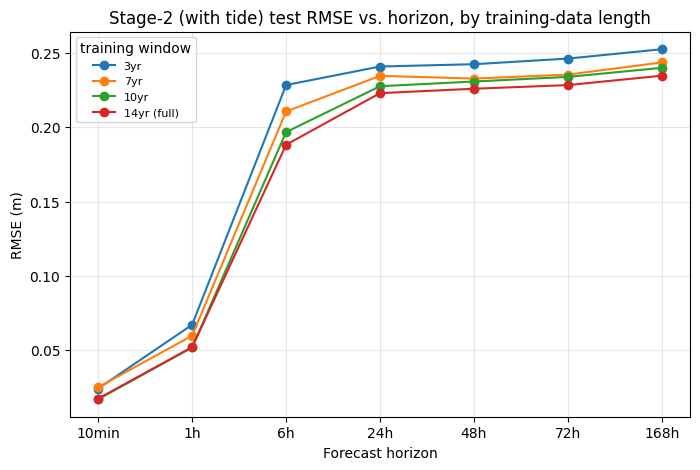

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_reduced_training_rmse_vs_horizon.png


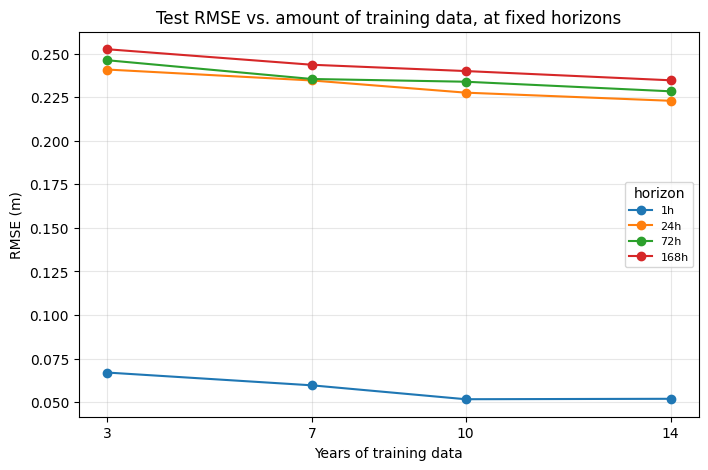

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_vs_training_years.png


In [39]:
print("UTide-standalone RMSE per training window (isolates constituent-fit quality from the neural net):")
print(utide_only_pivot.round(4))

plt.figure(figsize=(8, 5))
for name in reduced_pivot.index:
    plt.plot(HORIZON_NAMES, reduced_pivot.loc[name], marker='o', label=name)
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE (m)')
plt.title('Stage-2 (with tide) test RMSE vs. horizon, by training-data length')
plt.legend(title='training window', fontsize=8)
plt.grid(alpha=0.3)
reduced_plot_path = os.path.join(OUTPUT_DIR, 'stage2_reduced_training_rmse_vs_horizon.png')
plt.savefig(reduced_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {reduced_plot_path}")

fixed_horizons = ['1h', '24h', '72h', '168h']
plt.figure(figsize=(8, 5))
for hname in fixed_horizons:
    ys = [reduced_pivot.loc[name, hname] for name in train_years_order.index]
    plt.plot(train_years_order.values, ys, marker='o', label=hname)
plt.xlabel('Years of training data')
plt.ylabel('RMSE (m)')
plt.title('Test RMSE vs. amount of training data, at fixed horizons')
plt.legend(title='horizon', fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(sorted(train_years_order.unique()))
data_cliff_plot_path = os.path.join(OUTPUT_DIR, 'stage2_rmse_vs_training_years.png')
plt.savefig(data_cliff_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {data_cliff_plot_path}")

### 14.4 Summary

In [40]:
print("--- Section 14 summary ---")
print(f"14.1 Tide ablation: removing the tidal input changes test RMSE by "
      f"{tide_contribution_pct.mean():.1f}% on average across horizons "
      f"(range {tide_contribution_pct.min():.1f}% to {tide_contribution_pct.max():.1f}%).")

latest_yr, earliest_yr = year_pivot.index.max(), year_pivot.index.min()
yr_changes = ', '.join(
    f"{h}: {100 * (year_pivot.loc[latest_yr, h] / year_pivot.loc[earliest_yr, h] - 1):+.1f}%"
    for h in HORIZON_NAMES
)
print(f"14.2 Calendar-time drift: RMSE change from {earliest_yr} to {latest_yr} -- {yr_changes}")

print(f"14.3 Training-data reduction: at 24h horizon, RMSE goes from "
      f"{reduced_pivot.loc['14yr (full)', '24h']:.4f} m (14yr) to "
      f"{reduced_pivot.loc['3yr', '24h']:.4f} m (3yr) "
      f"({100 * (reduced_pivot.loc['3yr', '24h'] / reduced_pivot.loc['14yr (full)', '24h'] - 1):+.1f}%).")

print(f"\nAll section-14 outputs saved under: {OUTPUT_DIR}")

--- Section 14 summary ---
14.1 Tide ablation: removing the tidal input changes test RMSE by 35.4% on average across horizons (range 9.9% to 69.6%).
14.2 Calendar-time drift: RMSE change from 2021 to 2024 -- 10min: +0.6%, 1h: +3.4%, 6h: +8.2%, 24h: +5.1%, 48h: +5.7%, 72h: +6.6%, 168h: +9.8%
14.3 Training-data reduction: at 24h horizon, RMSE goes from 0.2230 m (14yr) to 0.2409 m (3yr) (+8.0%).

All section-14 outputs saved under: /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs
